In [17]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.12.0+rocm7.14.0
GPU available: True
GPU: AMD Radeon RX 7600 XT


In [18]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [19]:
print(dataset["train"][0])
print(dataset["train"][1])
print(dataset["train"][2])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [20]:
# Check the dataset structure
print("Dataset splits:")
print(dataset)

# Look at one review
print("\nFirst review:")
print(dataset["train"][0]["text"])

# Check its label
print("\nFirst review label:")
print(dataset["train"][0]["label"])

# Count the labels
print("\nLabel counts:")
print(dataset["train"].to_pandas()["label"].value_counts())

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

First review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between a

In [21]:
# Use smaller subsets for initial development
train_dataset = dataset["train"].shuffle(seed=42).select(range(5000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(1000))

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 5000
Testing samples: 1000


In [23]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [ ]:
def tokenize_reviews(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tokenized = train_dataset.map(tokenize_reviews, batched=True)
test_tokenized = test_dataset.map(tokenize_reviews, batched=True)

print("Tokenization complete!")
print(train_tokenized)

Tokenization complete!
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})


In [24]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!


In [25]:
print(dataset["train"].features["label"])

ClassLabel(names=['neg', 'pos'])


In [26]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

print("Training configuration created!")

Training configuration created!


In [27]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized
)

print("Trainer created successfully!")

Trainer created successfully!


In [ ]:
trainer.train()

c:\Users\theac\OneDrive\Documents\LoRA-Sentiment-Analysis\.venv\Lib\site-packages\transformers\integrations\sdpa_attention.py:154: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at B:\src\pytorch\aten\src\ATen\native\transformers\hip\sdp_utils.cpp:384.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Epoch,Training Loss,Validation Loss


c:\Users\theac\OneDrive\Documents\LoRA-Sentiment-Analysis\.venv\Lib\site-packages\transformers\integrations\sdpa_attention.py:154: UserWarning: Flash Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at B:\src\pytorch\aten\src\ATen\native\transformers\hip\sdp_utils.cpp:324.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


KeyboardInterrupt: 

In [28]:
predictions = trainer.predict(test_tokenized)

print("Evaluation complete!")
print(predictions.metrics)

Evaluation complete!
{'test_loss': 0.6943202018737793, 'test_model_preparation_time': 0.002, 'test_runtime': 12.4388, 'test_samples_per_second': 80.393, 'test_steps_per_second': 10.049}


In [29]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

predictions = trainer.predict(test_tokenized)

predicted_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

accuracy = accuracy_score(true_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    average="binary"
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.4910
Precision: 0.4588
Recall:    0.2398
F1 Score:  0.3149


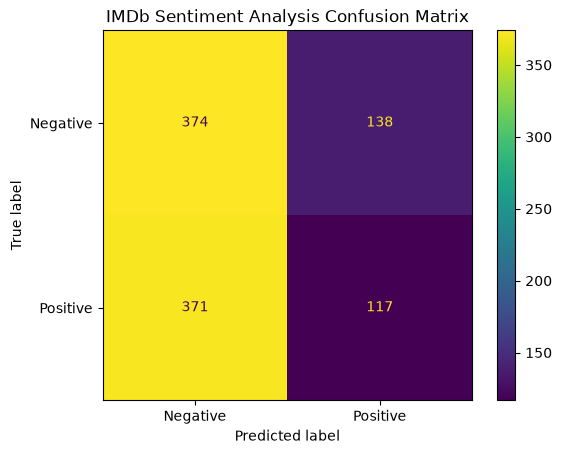

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("IMDb Sentiment Analysis Confusion Matrix")
plt.show()

In [31]:
review = "This movie was amazing! I really enjoyed it."

inputs = tokenizer(
    review,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)

inputs = {key: value.to(model.device) for key, value in inputs.items()}

outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1).item()

if prediction == 1:
    print("Positive")
else:
    print("Negative")

Positive


In [32]:
import torch
review = "I hated it, it literally took so long to finish"

inputs = tokenizer(
    review,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)

inputs = {key: value.to(model.device) for key, value in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1).item()

if prediction == 0:
    print("Prediction: NEGATIVE")
else:
    print("Prediction: POSITIVE")

Prediction: POSITIVE


In [33]:
trainer.save_model("./baseline_model")
tokenizer.save_pretrained("./baseline_model")

print("Baseline model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Baseline model saved successfully!


In [34]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "./baseline_model"
)

print("Baseline model loaded!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Baseline model loaded!


In [35]:
print(model.config.id2label)

{0: 'LABEL_0', 1: 'LABEL_1'}


In [36]:
import os

print(os.path.exists("./baseline_model"))

True


In [45]:
import torch

review = "This movie was terrible. I hated every second of it."

inputs = tokenizer(
    review,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)

inputs = {key: value.to(model.device) for key, value in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1).item()

if prediction == 0:
    print("Prediction: NEGATIVE")
else:
    print("Prediction: POSITIVE")

Prediction: POSITIVE


In [50]:
import torch

review = "An excellent movie with fantastic acting and a great story."

inputs = tokenizer(
    review,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)

inputs = {key: value.to(model.device) for key, value in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

probabilities = torch.softmax(outputs.logits, dim=1)

prediction = torch.argmax(probabilities, dim=1).item()

confidence = probabilities[0][prediction].item()

if prediction == 0:
    print("Prediction: NEGATIVE")
else:
    print("Prediction: POSITIVE")

print("Confidence:", confidence)

Prediction: POSITIVE
Confidence: 0.5043649673461914


In [51]:
print(model.config._name_or_path)

./baseline_model


In [52]:
print(model.classifier.weight[0][:5])

tensor([ 0.0041,  0.0034,  0.0006, -0.0110,  0.0106], grad_fn=<SliceBackward0>)


In [53]:
print(model.classifier.weight[1][:5])

tensor([-0.0243,  0.0180,  0.0275,  0.0100, -0.0113], grad_fn=<SliceBackward0>)


In [54]:
import torch

model.eval()

review = "The movie was absolutely fantastic. I loved every minute of it."

inputs = tokenizer(
    review,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)

inputs = {key: value.to(model.device) for key, value in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

probabilities = torch.softmax(outputs.logits, dim=1)

prediction = torch.argmax(probabilities, dim=1).item()

confidence = probabilities[0][prediction].item()

if prediction == 0:
    print("Prediction: NEGATIVE")
else:
    print("Prediction: POSITIVE")

print("Confidence:", confidence)

Prediction: NEGATIVE
Confidence: 0.5041472315788269


In [55]:
# Take one review from our test dataset
sample = test_dataset[0]

print("Review:")
print(sample["text"])

print("\nActual label:")
print(sample["label"])

Review:
<br /><br />When I unsuspectedly rented A Thousand Acres, I thought I was in for an entertaining King Lear story and of course Michelle Pfeiffer was in it, so what could go wrong?<br /><br />Very quickly, however, I realized that this story was about A Thousand Other Things besides just Acres. I started crying and couldn't stop until long after the movie ended. Thank you Jane, Laura and Jocelyn, for bringing us such a wonderfully subtle and compassionate movie! Thank you cast, for being involved and portraying the characters with such depth and gentleness!<br /><br />I recognized the Angry sister; the Runaway sister and the sister in Denial. I recognized the Abusive Husband and why he was there and then the Father, oh oh the Father... all superbly played. I also recognized myself and this movie was an eye-opener, a relief, a chance to face my OWN truth and finally doing something about it. I truly hope A Thousand Acres has had the same effect on some others out there.<br /><br 

In [56]:
review = sample["text"]

inputs = tokenizer(
    review,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)

inputs = {key: value.to(model.device) for key, value in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

probabilities = torch.softmax(outputs.logits, dim=1)

prediction = torch.argmax(probabilities, dim=1).item()

confidence = probabilities[0][prediction].item()

if prediction == 0:
    print("Prediction: NEGATIVE")
else:
    print("Prediction: POSITIVE")

print("Confidence:", confidence)

Prediction: NEGATIVE
Confidence: 0.5113052129745483


In [57]:
result = trainer.predict(test_tokenized.select([0]))

print("Actual label:", test_dataset[0]["label"])
print("Model prediction:", result.predictions.argmax(axis=1)[0])
print("Raw model scores:", result.predictions[0])

Actual label: 1
Model prediction: 0
Raw model scores: [-0.04864962 -0.09387807]


In [58]:
print(model.config.id2label)

{0: 'LABEL_0', 1: 'LABEL_1'}


In [59]:
model.config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

model.config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

print(model.config.id2label)
print(model.config.label2id)

{0: 'NEGATIVE', 1: 'POSITIVE'}
{'NEGATIVE': 0, 'POSITIVE': 1}


In [60]:
from peft import LoraConfig, get_peft_model

print("PEFT imported successfully!")

PEFT imported successfully!


In [61]:
print(model.config._name_or_path)

./baseline_model


In [62]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "./baseline_model"
)

model.config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

model.config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

print("Saved baseline model loaded.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Saved baseline model loaded.


In [63]:
from peft import LoraConfig

lora_config = LoraConfig(
    task_type="SEQ_CLS",
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

print("LoRA configuration created!")

LoRA configuration created!


In [64]:
from peft import get_peft_model

lora_model = get_peft_model(model, lora_config)

print("LoRA model created!")

LoRA model created!


In [65]:
lora_model.print_trainable_parameters()

trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [66]:
from transformers import Trainer

lora_trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized
)

print("LoRA trainer created!")

LoRA trainer created!


In [67]:
lora_trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.395696,0.367409
2,0.364114,0.357117


TrainOutput(global_step=1250, training_loss=0.4491317611694336, metrics={'train_runtime': 272.4186, 'train_samples_per_second': 36.708, 'train_steps_per_second': 4.589, 'total_flos': 673697034240000.0, 'train_loss': 0.4491317611694336, 'epoch': 2.0})

In [68]:
lora_results = lora_trainer.predict(test_tokenized)

print(lora_results.metrics)

{'test_loss': 0.35711684823036194, 'test_runtime': 12.6851, 'test_samples_per_second': 78.832, 'test_steps_per_second': 9.854}


In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

predictions = lora_results.predictions.argmax(axis=1)
true_labels = lora_results.label_ids

accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print("Accuracy: ", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:   ", round(recall, 4))
print("F1 Score: ", round(f1, 4))

Accuracy:  0.839
Precision: 0.8357
Recall:    0.834
F1 Score:  0.8349


In [70]:
from peft import LoraConfig

lora_config_16 = LoraConfig(
    task_type="SEQ_CLS",
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

print("LoRA r=16 configuration created!")

LoRA r=16 configuration created!


In [71]:
lora_model_16 = get_peft_model(model, lora_config_16)

print("LoRA r=16 model created!")

LoRA r=16 model created!


c:\Users\theac\OneDrive\Documents\LoRA-Sentiment-Analysis\.venv\Lib\site-packages\peft\mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
c:\Users\theac\OneDrive\Documents\LoRA-Sentiment-Analysis\.venv\Lib\site-packages\peft\tuners\tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [72]:
lora_model_16.print_trainable_parameters()

trainable params: 887,042 || all params: 67,842,052 || trainable%: 1.3075


In [74]:
lora_trainer_16 = Trainer(
    model=lora_model_16,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized
)

print("r=16 Trainer created!")

r=16 Trainer created!


In [75]:
lora_trainer_16.train()

Epoch,Training Loss,Validation Loss
1,0.374157,0.358723
2,0.349633,0.350765


TrainOutput(global_step=1250, training_loss=0.3855569046020508, metrics={'train_runtime': 272.1445, 'train_samples_per_second': 36.745, 'train_steps_per_second': 4.593, 'total_flos': 675961958400000.0, 'train_loss': 0.3855569046020508, 'epoch': 2.0})

In [76]:
lora_results_16 = lora_trainer_16.predict(test_tokenized)

print(lora_results_16.metrics)

{'test_loss': 0.35076507925987244, 'test_runtime': 12.6956, 'test_samples_per_second': 78.767, 'test_steps_per_second': 9.846}


In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

predictions_16 = lora_results_16.predictions.argmax(axis=1)
true_labels_16 = lora_results_16.label_ids

accuracy_16 = accuracy_score(true_labels_16, predictions_16)
precision_16 = precision_score(true_labels_16, predictions_16)
recall_16 = recall_score(true_labels_16, predictions_16)
f1_16 = f1_score(true_labels_16, predictions_16)

print("Accuracy: ", round(accuracy_16, 4))
print("Precision:", round(precision_16, 4))
print("Recall:   ", round(recall_16, 4))
print("F1 Score: ", round(f1_16, 4))

Accuracy:  0.848
Precision: 0.8387
Recall:    0.8525
F1 Score:  0.8455


In [78]:
from transformers import AutoModelForSequenceClassification

model_32_base = AutoModelForSequenceClassification.from_pretrained(
    "./baseline_model"
)

model_32_base.config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

model_32_base.config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

print("Baseline model for r=32 loaded!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Baseline model for r=32 loaded!


In [79]:
from peft import LoraConfig

lora_config_32 = LoraConfig(
    task_type="SEQ_CLS",
    r=32,
    lora_alpha=64,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

print("LoRA r=32 configuration created!")

LoRA r=32 configuration created!


In [80]:
from peft import get_peft_model

lora_model_32 = get_peft_model(
    model_32_base,
    lora_config_32
)

print("LoRA r=32 model created!")

LoRA r=32 model created!


In [81]:
lora_model_32.print_trainable_parameters()

trainable params: 1,181,954 || all params: 68,136,964 || trainable%: 1.7347


In [82]:
lora_trainer_32 = Trainer(
    model=lora_model_32,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized
)

print("r=32 Trainer created!")

r=32 Trainer created!


In [83]:
lora_trainer_32.train()

Epoch,Training Loss,Validation Loss
1,0.372674,0.361355
2,0.340958,0.345467


TrainOutput(global_step=1250, training_loss=0.40847509841918944, metrics={'train_runtime': 287.0027, 'train_samples_per_second': 34.843, 'train_steps_per_second': 4.355, 'total_flos': 680491806720000.0, 'train_loss': 0.40847509841918944, 'epoch': 2.0})

In [84]:
lora_results_32 = lora_trainer_32.predict(test_tokenized)

print(lora_results_32.metrics)

{'test_loss': 0.345467209815979, 'test_runtime': 13.0433, 'test_samples_per_second': 76.668, 'test_steps_per_second': 9.583}


In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

predictions_32 = lora_results_32.predictions.argmax(axis=1)
true_labels_32 = lora_results_32.label_ids

accuracy_32 = accuracy_score(true_labels_32, predictions_32)
precision_32 = precision_score(true_labels_32, predictions_32)
recall_32 = recall_score(true_labels_32, predictions_32)
f1_32 = f1_score(true_labels_32, predictions_32)

print("Accuracy: ", round(accuracy_32, 4))
print("Precision:", round(precision_32, 4))
print("Recall:   ", round(recall_32, 4))
print("F1 Score: ", round(f1_32, 4))

Accuracy:  0.854
Precision: 0.834
Recall:    0.875
F1 Score:  0.854


In [86]:
from peft import LoraConfig

lora_config_64 = LoraConfig(
    task_type="SEQ_CLS",
    r=64,
    lora_alpha=128,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

print("LoRA r=64 configuration created!")

LoRA r=64 configuration created!


In [87]:
from peft import get_peft_model

lora_model_64 = get_peft_model(
    model_32_base,
    lora_config_64
)

print("LoRA r=64 model created!")

LoRA r=64 model created!


c:\Users\theac\OneDrive\Documents\LoRA-Sentiment-Analysis\.venv\Lib\site-packages\peft\mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
c:\Users\theac\OneDrive\Documents\LoRA-Sentiment-Analysis\.venv\Lib\site-packages\peft\tuners\tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [88]:
lora_model_64.print_trainable_parameters()

trainable params: 1,771,778 || all params: 68,726,788 || trainable%: 2.5780


In [89]:
from transformers import Trainer

lora_trainer_64 = Trainer(
    model=lora_model_64,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized
)

print("r=64 Trainer created!")

r=64 Trainer created!


In [90]:
lora_trainer_64.train()

Epoch,Training Loss,Validation Loss
1,0.358942,0.356462
2,0.328235,0.336163


TrainOutput(global_step=1250, training_loss=0.3582884010314941, metrics={'train_runtime': 287.2697, 'train_samples_per_second': 34.81, 'train_steps_per_second': 4.351, 'total_flos': 689551503360000.0, 'train_loss': 0.3582884010314941, 'epoch': 2.0})

In [91]:
lora_results_64 = lora_trainer_64.predict(test_tokenized)

print(lora_results_64.metrics)

{'test_loss': 0.3361632823944092, 'test_runtime': 13.189, 'test_samples_per_second': 75.821, 'test_steps_per_second': 9.478}


In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

predictions_64 = lora_results_64.predictions.argmax(axis=1)
true_labels_64 = lora_results_64.label_ids

accuracy_64 = accuracy_score(true_labels_64, predictions_64)
precision_64 = precision_score(true_labels_64, predictions_64)
recall_64 = recall_score(true_labels_64, predictions_64)
f1_64 = f1_score(true_labels_64, predictions_64)

print("Accuracy: ", round(accuracy_64, 4))
print("Precision:", round(precision_64, 4))
print("Recall:   ", round(recall_64, 4))
print("F1 Score: ", round(f1_64, 4))

Accuracy:  0.854
Precision: 0.8379
Recall:    0.8689
F1 Score:  0.8531


In [93]:
from transformers import TrainingArguments

training_args_lr = TrainingArguments(
    output_dir="./lora_lr_results",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

print("Higher learning-rate configuration created!")

Higher learning-rate configuration created!


In [94]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model

model_lr = AutoModelForSequenceClassification.from_pretrained(
    "./baseline_model"
)

lora_config_lr = LoraConfig(
    task_type="SEQ_CLS",
    r=32,
    lora_alpha=64,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

lora_model_lr = get_peft_model(
    model_lr,
    lora_config_lr
)

print("Fresh r=32 model created!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Fresh r=32 model created!


In [95]:
lora_model_lr.print_trainable_parameters()

trainable params: 1,181,954 || all params: 68,136,964 || trainable%: 1.7347


In [96]:
lora_trainer_lr = Trainer(
    model=lora_model_lr,
    args=training_args_lr,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized
)

print("Higher learning-rate Trainer created!")

Higher learning-rate Trainer created!


In [97]:
lora_trainer_lr.train()

Epoch,Training Loss,Validation Loss
1,0.407384,0.370746
2,0.311737,0.324291


TrainOutput(global_step=1250, training_loss=0.3595606689453125, metrics={'train_runtime': 283.5405, 'train_samples_per_second': 35.268, 'train_steps_per_second': 4.409, 'total_flos': 680491806720000.0, 'train_loss': 0.3595606689453125, 'epoch': 2.0})

In [98]:
lora_results_lr = lora_trainer_lr.predict(test_tokenized)

print(lora_results_lr.metrics)

{'test_loss': 0.324291467666626, 'test_runtime': 12.7734, 'test_samples_per_second': 78.288, 'test_steps_per_second': 9.786}


In [99]:
predictions_lr = lora_results_lr.predictions.argmax(axis=1)
true_labels_lr = lora_results_lr.label_ids

accuracy_lr = accuracy_score(true_labels_lr, predictions_lr)
precision_lr = precision_score(true_labels_lr, predictions_lr)
recall_lr = recall_score(true_labels_lr, predictions_lr)
f1_lr = f1_score(true_labels_lr, predictions_lr)

print("Accuracy: ", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall:   ", round(recall_lr, 4))
print("F1 Score: ", round(f1_lr, 4))

Accuracy:  0.86
Precision: 0.8439
Recall:    0.875
F1 Score:  0.8592


In [100]:
training_args_lr2 = TrainingArguments(
    output_dir="./lora_lr2_results",
    learning_rate=1e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

print("1e-4 learning-rate configuration created!")

1e-4 learning-rate configuration created!


In [101]:
model_lr2 = AutoModelForSequenceClassification.from_pretrained(
    "./baseline_model"
)

model_lr2.config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

model_lr2.config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

print("Fresh baseline model loaded!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Fresh baseline model loaded!


In [102]:
lora_config_lr2 = LoraConfig(
    task_type="SEQ_CLS",
    r=32,
    lora_alpha=64,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

print("r=32 LoRA configuration created!")

r=32 LoRA configuration created!


In [103]:
lora_model_lr2 = get_peft_model(
    model_lr2,
    lora_config_lr2
)

print("r=32 LoRA model created!")

r=32 LoRA model created!


In [104]:
lora_model_lr2.print_trainable_parameters()

trainable params: 1,181,954 || all params: 68,136,964 || trainable%: 1.7347


In [105]:
lora_trainer_lr2 = Trainer(
    model=lora_model_lr2,
    args=training_args_lr2,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized
)

print("1e-4 Trainer created!")

1e-4 Trainer created!


In [106]:
lora_trainer_lr2.train()

Epoch,Training Loss,Validation Loss
1,0.381732,0.341598
2,0.289616,0.316696


TrainOutput(global_step=1250, training_loss=0.33567354736328125, metrics={'train_runtime': 280.3217, 'train_samples_per_second': 35.673, 'train_steps_per_second': 4.459, 'total_flos': 680491806720000.0, 'train_loss': 0.33567354736328125, 'epoch': 2.0})

In [107]:
lora_results_lr2 = lora_trainer_lr2.predict(test_tokenized)

print(lora_results_lr2.metrics)

{'test_loss': 0.3166961073875427, 'test_runtime': 13.0795, 'test_samples_per_second': 76.456, 'test_steps_per_second': 9.557}


In [108]:
predictions_lr2 = lora_results_lr2.predictions.argmax(axis=1)
true_labels_lr2 = lora_results_lr2.label_ids

accuracy_lr2 = accuracy_score(true_labels_lr2, predictions_lr2)
precision_lr2 = precision_score(true_labels_lr2, predictions_lr2)
recall_lr2 = recall_score(true_labels_lr2, predictions_lr2)
f1_lr2 = f1_score(true_labels_lr2, predictions_lr2)

print("Accuracy: ", round(accuracy_lr2, 4))
print("Precision:", round(precision_lr2, 4))
print("Recall:   ", round(recall_lr2, 4))
print("F1 Score: ", round(f1_lr2, 4))

Accuracy:  0.869
Precision: 0.848
Recall:    0.8914
F1 Score:  0.8691


In [109]:
training_args_lr3 = TrainingArguments(
    output_dir="./lora_lr3_results",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

print("2e-4 learning-rate configuration created!")

2e-4 learning-rate configuration created!


In [110]:
model_lr3 = AutoModelForSequenceClassification.from_pretrained(
    "./baseline_model"
)

model_lr3.config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

model_lr3.config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

print("Fresh baseline model loaded!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Fresh baseline model loaded!


In [111]:
lora_config_lr3 = LoraConfig(
    task_type="SEQ_CLS",
    r=32,
    lora_alpha=64,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

print("r=32 LoRA configuration created!")

r=32 LoRA configuration created!


In [112]:
lora_model_lr3 = get_peft_model(
    model_lr3,
    lora_config_lr3
)

print("r=32 LoRA model created!")

r=32 LoRA model created!


In [113]:
lora_model_lr3.print_trainable_parameters()

trainable params: 1,181,954 || all params: 68,136,964 || trainable%: 1.7347


In [114]:
lora_trainer_lr3 = Trainer(
    model=lora_model_lr3,
    args=training_args_lr3,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized
)

print("2e-4 Trainer created!")

2e-4 Trainer created!


In [115]:
lora_trainer_lr3.train()

Epoch,Training Loss,Validation Loss
1,0.366297,0.339501
2,0.268153,0.332615


TrainOutput(global_step=1250, training_loss=0.3172249145507812, metrics={'train_runtime': 282.3733, 'train_samples_per_second': 35.414, 'train_steps_per_second': 4.427, 'total_flos': 680491806720000.0, 'train_loss': 0.3172249145507812, 'epoch': 2.0})

In [116]:
lora_results_lr3 = lora_trainer_lr3.predict(test_tokenized)

print(lora_results_lr3.metrics)

{'test_loss': 0.3326154351234436, 'test_runtime': 12.7672, 'test_samples_per_second': 78.326, 'test_steps_per_second': 9.791}


In [117]:
predictions_lr3 = lora_results_lr3.predictions.argmax(axis=1)
true_labels_lr3 = lora_results_lr3.label_ids

accuracy_lr3 = accuracy_score(true_labels_lr3, predictions_lr3)
precision_lr3 = precision_score(true_labels_lr3, predictions_lr3)
recall_lr3 = recall_score(true_labels_lr3, predictions_lr3)
f1_lr3 = f1_score(true_labels_lr3, predictions_lr3)

print("Accuracy: ", round(accuracy_lr3, 4))
print("Precision:", round(precision_lr3, 4))
print("Recall:   ", round(recall_lr3, 4))
print("F1 Score: ", round(f1_lr3, 4))

Accuracy:  0.864
Precision: 0.8398
Recall:    0.8914
F1 Score:  0.8648


In [118]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions from our best model
predictions_best = lora_results_lr2.predictions.argmax(axis=1)
true_labels_best = lora_results_lr2.label_ids

# Create confusion matrix
cm = confusion_matrix(true_labels_best, predictions_best)

print(cm)

[[434  78]
 [ 53 435]]


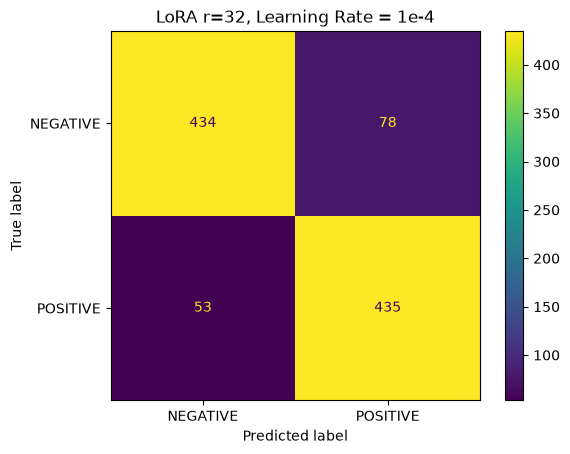

In [119]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NEGATIVE", "POSITIVE"]
)

disp.plot()
plt.title("LoRA r=32, Learning Rate = 1e-4")
plt.show()

In [120]:
wrong_predictions = []

for i in range(len(test_dataset)):
    actual = true_labels_best[i]
    predicted = predictions_best[i]

    if actual != predicted:
        wrong_predictions.append({
            "index": i,
            "actual": actual,
            "predicted": predicted,
            "text": test_dataset[i]["text"]
        })

print("Number of incorrect predictions:", len(wrong_predictions))

Number of incorrect predictions: 131


In [121]:
for review in wrong_predictions[:5]:
    print("Index:", review["index"])
    print("Actual:", "POSITIVE" if review["actual"] == 1 else "NEGATIVE")
    print("Predicted:", "POSITIVE" if review["predicted"] == 1 else "NEGATIVE")
    print("Review:", review["text"])
    print("-" * 80)

Index: 21
Actual: NEGATIVE
Predicted: POSITIVE
Review: Coming from Kiarostami, this art-house visual and sound exposition is a surprise. For a director known for his narratives and keen observation of humans, especially children, this excursion into minimalist cinematography begs for questions: Why did he do it? Was it to keep him busy during a vacation at the shore? <br /><br />"Five, 5 Long Takes" consists of, you guessed it, five long takes. They are (the title names are my own and the times approximate): <br /><br />"Driftwood and waves". The camera stands nearly still looking at a small piece of driftwood as it gets moved around by small waves splashing on a beach. Ten minutes.<br /><br />"Watching people on the boardwalk". The camera stands still looking at the ocean horizon and a boardwalk. People walk across the camera frame, their faces too far and blurry to make them interesting. Eleven minutes.<br /><br />"Six dogs at the water's edge". The camera stands still looking at the

In [122]:
print("Confusion Matrix:")
print(cm)

print("\nTrue Negative:", cm[0][0])
print("False Positive:", cm[0][1])
print("False Negative:", cm[1][0])
print("True Positive:", cm[1][1])

Confusion Matrix:
[[434  78]
 [ 53 435]]

True Negative: 434
False Positive: 78
False Negative: 53
True Positive: 435


In [123]:
false_positives = []

false_negatives = []

for i in range(len(test_dataset)):
    actual = true_labels_best[i]
    predicted = predictions_best[i]

    if actual == 0 and predicted == 1:
        false_positives.append({
            "index": i,
            "text": test_dataset[i]["text"]
        })

    elif actual == 1 and predicted == 0:
        false_negatives.append({
            "index": i,
            "text": test_dataset[i]["text"]
        })

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 78
False negatives: 53


In [124]:
print("\n--- FALSE POSITIVES ---")

for review in false_positives[:5]:
    print("Index:", review["index"])
    print("Review:", review["text"])
    print("-" * 80)

print("\n--- FALSE NEGATIVES ---")

for review in false_negatives[:5]:
    print("Index:", review["index"])
    print("Review:", review["text"])
    print("-" * 80)


--- FALSE POSITIVES ---
Index: 21
Review: Coming from Kiarostami, this art-house visual and sound exposition is a surprise. For a director known for his narratives and keen observation of humans, especially children, this excursion into minimalist cinematography begs for questions: Why did he do it? Was it to keep him busy during a vacation at the shore? <br /><br />"Five, 5 Long Takes" consists of, you guessed it, five long takes. They are (the title names are my own and the times approximate): <br /><br />"Driftwood and waves". The camera stands nearly still looking at a small piece of driftwood as it gets moved around by small waves splashing on a beach. Ten minutes.<br /><br />"Watching people on the boardwalk". The camera stands still looking at the ocean horizon and a boardwalk. People walk across the camera frame, their faces too far and blurry to make them interesting. Eleven minutes.<br /><br />"Six dogs at the water's edge". The camera stands still looking at the ocean horiz

In [125]:
baseline_trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=test_tokenized
)

baseline_results = baseline_trainer.predict(test_tokenized)

baseline_predictions = baseline_results.predictions.argmax(axis=1)
baseline_true_labels = baseline_results.label_ids

print("Baseline predictions generated!")

Baseline predictions generated!


In [126]:
baseline_cm = confusion_matrix(
    baseline_true_labels,
    baseline_predictions
)

print("Baseline Confusion Matrix:")
print(baseline_cm)

print("\nBaseline Accuracy:",
      accuracy_score(baseline_true_labels, baseline_predictions))

Baseline Confusion Matrix:
[[432  80]
 [ 72 416]]

Baseline Accuracy: 0.848


In [127]:
from transformers import AutoModelForSequenceClassification

# Load a completely fresh baseline model
true_baseline_model = AutoModelForSequenceClassification.from_pretrained(
    "./baseline_model"
)

true_baseline_model.config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

true_baseline_model.config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

print("Fresh baseline model loaded!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Fresh baseline model loaded!


In [128]:
true_baseline_trainer = Trainer(
    model=true_baseline_model,
    args=training_args,
    eval_dataset=test_tokenized
)

print("Fresh baseline trainer created!")

Fresh baseline trainer created!


In [129]:
true_baseline_results = true_baseline_trainer.predict(test_tokenized)

true_baseline_predictions = (
    true_baseline_results.predictions.argmax(axis=1)
)

true_baseline_labels = true_baseline_results.label_ids

print("Baseline test results:")
print(true_baseline_results.metrics)

Baseline test results:
{'test_loss': 0.6943202018737793, 'test_model_preparation_time': 0.001, 'test_runtime': 12.8055, 'test_samples_per_second': 78.092, 'test_steps_per_second': 9.761}


In [130]:
true_baseline_accuracy = accuracy_score(
    true_baseline_labels,
    true_baseline_predictions
)

true_baseline_precision = precision_score(
    true_baseline_labels,
    true_baseline_predictions
)

true_baseline_recall = recall_score(
    true_baseline_labels,
    true_baseline_predictions
)

true_baseline_f1 = f1_score(
    true_baseline_labels,
    true_baseline_predictions
)

print("Accuracy: ", round(true_baseline_accuracy, 4))
print("Precision:", round(true_baseline_precision, 4))
print("Recall:   ", round(true_baseline_recall, 4))
print("F1 Score: ", round(true_baseline_f1, 4))

Accuracy:  0.491
Precision: 0.4588
Recall:    0.2398
F1 Score:  0.3149


In [131]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles and folders:")
for item in os.listdir("."):
    print(item)

Current directory:
c:\Users\theac\OneDrive\Documents\LoRA-Sentiment-Analysis

Files and folders:
.venv
01_baseline.ipynb
baseline_model
lora_lr2_results
lora_lr3_results
lora_lr_results
results


In [132]:
import glob

print("\nPossible checkpoints:")

for path in glob.glob("**/checkpoint-*", recursive=True):
    print(path)


Possible checkpoints:
results\checkpoint-1250
results\checkpoint-625


In [133]:
print("\nPossible model folders:")

for path in glob.glob("**/pytorch_model.bin", recursive=True):
    print(path)

for path in glob.glob("**/model.safetensors", recursive=True):
    print(path)


Possible model folders:
baseline_model\model.safetensors
results\checkpoint-1250\model.safetensors
results\checkpoint-625\model.safetensors


In [134]:
from transformers import AutoModelForSequenceClassification, Trainer

# Load the trained baseline from disk
saved_baseline = AutoModelForSequenceClassification.from_pretrained(
    "./baseline_model"
)

saved_baseline.config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

saved_baseline.config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

# Create evaluator
saved_baseline_trainer = Trainer(
    model=saved_baseline,
    args=training_args,
    eval_dataset=test_tokenized
)

# Evaluate
saved_baseline_results = saved_baseline_trainer.predict(test_tokenized)

saved_baseline_predictions = (
    saved_baseline_results.predictions.argmax(axis=1)
)

saved_baseline_true_labels = saved_baseline_results.label_ids

print("Baseline test results:")
print(saved_baseline_results.metrics)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Baseline test results:
{'test_loss': 0.6943202018737793, 'test_model_preparation_time': 0.002, 'test_runtime': 12.8356, 'test_samples_per_second': 77.908, 'test_steps_per_second': 9.739}


In [135]:
baseline_accuracy = accuracy_score(
    saved_baseline_true_labels,
    saved_baseline_predictions
)

baseline_precision = precision_score(
    saved_baseline_true_labels,
    saved_baseline_predictions
)

baseline_recall = recall_score(
    saved_baseline_true_labels,
    saved_baseline_predictions
)

baseline_f1 = f1_score(
    saved_baseline_true_labels,
    saved_baseline_predictions
)

print("Baseline Accuracy: ", round(baseline_accuracy, 4))
print("Baseline Precision:", round(baseline_precision, 4))
print("Baseline Recall:   ", round(baseline_recall, 4))
print("Baseline F1 Score: ", round(baseline_f1, 4))

Baseline Accuracy:  0.491
Baseline Precision: 0.4588
Baseline Recall:    0.2398
Baseline F1 Score:  0.3149


In [136]:
# Save the ACTUALLY TRAINED baseline model
baseline_trainer.model.save_pretrained("./baseline_model")
tokenizer.save_pretrained("./baseline_model")

print("Trained baseline model saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Trained baseline model saved!


In [137]:
from transformers import AutoModelForSequenceClassification, Trainer

# Reload the trained baseline from disk
saved_baseline = AutoModelForSequenceClassification.from_pretrained(
    "./baseline_model"
)

saved_baseline.config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

saved_baseline.config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

saved_baseline_trainer = Trainer(
    model=saved_baseline,
    args=training_args,
    eval_dataset=test_tokenized
)

saved_baseline_results = saved_baseline_trainer.predict(test_tokenized)

saved_baseline_predictions = (
    saved_baseline_results.predictions.argmax(axis=1)
)

saved_baseline_true_labels = saved_baseline_results.label_ids

print("Reloaded baseline results:")
print(saved_baseline_results.metrics)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: ./baseline_model
Key                                                                                   | Status     | 
--------------------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.base_layer.bias       | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_B.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.base_layer.weight     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_A.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.lora_A.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.base_layer.weight     | UNEXPECTED | 
pre_classifier.modules_to_save.default.weight                                         | UNEXPECTED

Reloaded baseline results:
{'test_loss': 0.6999643445014954, 'test_model_preparation_time': 0.0025, 'test_runtime': 12.6018, 'test_samples_per_second': 79.354, 'test_steps_per_second': 9.919}


In [138]:
baseline_accuracy = accuracy_score(
    saved_baseline_true_labels,
    saved_baseline_predictions
)

baseline_precision = precision_score(
    saved_baseline_true_labels,
    saved_baseline_predictions
)

baseline_recall = recall_score(
    saved_baseline_true_labels,
    saved_baseline_predictions
)

baseline_f1 = f1_score(
    saved_baseline_true_labels,
    saved_baseline_predictions
)

print("Baseline Accuracy: ", round(baseline_accuracy, 4))
print("Baseline Precision:", round(baseline_precision, 4))
print("Baseline Recall:   ", round(baseline_recall, 4))
print("Baseline F1 Score: ", round(baseline_f1, 4))

Baseline Accuracy:  0.488
Baseline Precision: 0.488
Baseline Recall:    1.0
Baseline F1 Score:  0.6559


In [139]:
from sklearn.metrics import confusion_matrix, classification_report

# Best LoRA predictions
best_cm = confusion_matrix(true_labels_best, predictions_best)

print("BEST LoRA CONFUSION MATRIX:")
print(best_cm)

print("\nTrue Negative:", best_cm[0][0])
print("False Positive:", best_cm[0][1])
print("False Negative:", best_cm[1][0])
print("True Positive:", best_cm[1][1])

print("\n--- BEST LoRA CLASSIFICATION REPORT ---")
print(
    classification_report(
        true_labels_best,
        predictions_best,
        target_names=["NEGATIVE", "POSITIVE"]
    )
)

# Valid baseline predictions from earlier in-memory evaluation
baseline_cm = confusion_matrix(
    baseline_true_labels,
    baseline_predictions
)

print("\n--- BASELINE CONFUSION MATRIX ---")
print(baseline_cm)

print("\nBaseline True Negative:", baseline_cm[0][0])
print("Baseline False Positive:", baseline_cm[0][1])
print("Baseline False Negative:", baseline_cm[1][0])
print("Baseline True Positive:", baseline_cm[1][1])

BEST LoRA CONFUSION MATRIX:
[[434  78]
 [ 53 435]]

True Negative: 434
False Positive: 78
False Negative: 53
True Positive: 435

--- BEST LoRA CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    NEGATIVE       0.89      0.85      0.87       512
    POSITIVE       0.85      0.89      0.87       488

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000


--- BASELINE CONFUSION MATRIX ---
[[432  80]
 [ 72 416]]

Baseline True Negative: 432
Baseline False Positive: 80
Baseline False Negative: 72
Baseline True Positive: 416


In [140]:
print("\n========== BASELINE vs BEST LoRA ==========")

print(f"Baseline Accuracy: {accuracy_score(baseline_true_labels, baseline_predictions):.4f}")
print(f"LoRA Accuracy:     {accuracy_score(true_labels_best, predictions_best):.4f}")

print(f"\nBaseline F1: {f1_score(baseline_true_labels, baseline_predictions):.4f}")
print(f"LoRA F1:     {f1_score(true_labels_best, predictions_best):.4f}")

print("\nAccuracy improvement:",
      f"{(accuracy_score(true_labels_best, predictions_best) - "
      "accuracy_score(baseline_true_labels, baseline_predictions)) * 100:.2f} percentage points")

SyntaxError: f-string: expecting '}' (3376082038.py, line 10)

In [141]:
print("\n========== BASELINE vs BEST LoRA ==========")

baseline_acc = accuracy_score(
    baseline_true_labels,
    baseline_predictions
)

lora_acc = accuracy_score(
    true_labels_best,
    predictions_best
)

baseline_f1_score = f1_score(
    baseline_true_labels,
    baseline_predictions
)

lora_f1_score = f1_score(
    true_labels_best,
    predictions_best
)

print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"LoRA Accuracy:     {lora_acc:.4f}")

print(f"\nBaseline F1: {baseline_f1_score:.4f}")
print(f"LoRA F1:     {lora_f1_score:.4f}")

print(f"\nAccuracy improvement: {(lora_acc - baseline_acc) * 100:.2f} percentage points")


========== BASELINE vs BEST LoRA ==========
Baseline Accuracy: 0.8480
LoRA Accuracy:     0.8690

Baseline F1: 0.8455
LoRA F1:     0.8691

Accuracy improvement: 2.10 percentage points


In [142]:
# Find examples where:
# Baseline was WRONG, but LoRA was CORRECT

baseline_wrong_lora_correct = []

# Find examples where:
# Baseline was CORRECT, but LoRA was WRONG

baseline_correct_lora_wrong = []

# Find examples where:
# BOTH models were WRONG

both_wrong = []

for i in range(len(test_dataset)):
    actual = true_labels_best[i]
    baseline_pred = baseline_predictions[i]
    lora_pred = predictions_best[i]

    if baseline_pred != actual and lora_pred == actual:
        baseline_wrong_lora_correct.append({
            "index": i,
            "actual": actual,
            "baseline": baseline_pred,
            "lora": lora_pred,
            "text": test_dataset[i]["text"]
        })

    elif baseline_pred == actual and lora_pred != actual:
        baseline_correct_lora_wrong.append({
            "index": i,
            "actual": actual,
            "baseline": baseline_pred,
            "lora": lora_pred,
            "text": test_dataset[i]["text"]
        })

    elif baseline_pred != actual and lora_pred != actual:
        both_wrong.append({
            "index": i,
            "actual": actual,
            "baseline": baseline_pred,
            "lora": lora_pred,
            "text": test_dataset[i]["text"]
        })

print("Baseline wrong → LoRA correct:", len(baseline_wrong_lora_correct))
print("Baseline correct → LoRA wrong:", len(baseline_correct_lora_wrong))
print("Both wrong:", len(both_wrong))

Baseline wrong → LoRA correct: 53
Baseline correct → LoRA wrong: 32
Both wrong: 99


In [143]:
print("\n===== BASELINE WRONG → LoRA CORRECT =====")

for review in baseline_wrong_lora_correct[:10]:
    print("Index:", review["index"])
    print("Actual:", review["actual"])
    print("Baseline:", review["baseline"])
    print("LoRA:", review["lora"])
    print("Review:", review["text"])
    print("-" * 80)


print("\n===== BASELINE CORRECT → LoRA WRONG =====")

for review in baseline_correct_lora_wrong[:10]:
    print("Index:", review["index"])
    print("Actual:", review["actual"])
    print("Baseline:", review["baseline"])
    print("LoRA:", review["lora"])
    print("Review:", review["text"])
    print("-" * 80)


===== BASELINE WRONG → LoRA CORRECT =====
Index: 50
Actual: 1
Baseline: 0
LoRA: 1
Review: Fantastic Chaplin movie with many memorable moments as Charlie joins the army to fight in WW 1.<br /><br />At first he goes to boot camp, where he has to learn how to handle his rifle and how to walk in line. That's a really funny scene as the tramp is not used to keeping his feet straight!<br /><br />Next thing you know he's in France in a trench. Hilarious scenes here include a starving Charlie eating the cheese of a mousetrap and reading a letter from home over someone's shoulder.<br /><br />When Charlie goes to sleep he finds his bunker all flooded and his roommate snoring. This is such a funny part! I can't really describe it, just watch the movie. When Charlie wakes up his legs feel numb so he tries to 'wake them up'. It had me rolling on the floor when it turns out his second leg still feels numb... while Charlie actually rubs his roommate's foot!<br /><br />The movie then turns a bit grim

In [144]:
print("===== EXAMPLES LO RA FIXED =====")

for review in baseline_wrong_lora_correct:
    print(
        f"Index: {review['index']} | "
        f"Actual: {'POSITIVE' if review['actual'] == 1 else 'NEGATIVE'} | "
        f"Baseline: {'POSITIVE' if review['baseline'] == 1 else 'NEGATIVE'} | "
        f"LoRA: {'POSITIVE' if review['lora'] == 1 else 'NEGATIVE'}"
    )
    print("Review:", review["text"])
    print("-" * 100)

===== EXAMPLES LO RA FIXED =====
Index: 50 | Actual: POSITIVE | Baseline: NEGATIVE | LoRA: POSITIVE
Review: Fantastic Chaplin movie with many memorable moments as Charlie joins the army to fight in WW 1.<br /><br />At first he goes to boot camp, where he has to learn how to handle his rifle and how to walk in line. That's a really funny scene as the tramp is not used to keeping his feet straight!<br /><br />Next thing you know he's in France in a trench. Hilarious scenes here include a starving Charlie eating the cheese of a mousetrap and reading a letter from home over someone's shoulder.<br /><br />When Charlie goes to sleep he finds his bunker all flooded and his roommate snoring. This is such a funny part! I can't really describe it, just watch the movie. When Charlie wakes up his legs feel numb so he tries to 'wake them up'. It had me rolling on the floor when it turns out his second leg still feels numb... while Charlie actually rubs his roommate's foot!<br /><br />The movie then

In [145]:
print("\n===== EXAMPLES WHERE LoRA REGRESSED =====")

for review in baseline_correct_lora_wrong:
    print(
        f"Index: {review['index']} | "
        f"Actual: {'POSITIVE' if review['actual'] == 1 else 'NEGATIVE'} | "
        f"Baseline: {'POSITIVE' if review['baseline'] == 1 else 'NEGATIVE'} | "
        f"LoRA: {'POSITIVE' if review['lora'] == 1 else 'NEGATIVE'}"
    )
    print("Review:", review["text"])
    print("-" * 100)


===== EXAMPLES WHERE LoRA REGRESSED =====
Index: 38 | Actual: NEGATIVE | Baseline: NEGATIVE | LoRA: POSITIVE
Review: A very sensitive topic--15 y/o girl abandoned by mother as a baby and who goes to visit her, continues to be ignored, is raped by her mom's boyfriend, becomes pregnant. There was not enough depth displayed of this situation. Too much of time is taken up on the chase with the truckers transporting the baby. (Interesting, this baby with asthma--you never see him cry-- except once--, be fed, have is diaper changed during the whole truck transport ordeal.) I would have liked to have seen more of the interrelationships, more focus on the fact that this girl was a minor--this should have stood up in court immediately.<br /><br />And this was a true story! It deserved a better telling than that!!<br /><br />If it weren't for the subject matter, I would have given this closer to a 0 rating. I rented this from the library. Only later I found out it was a made for TV movie. <br /

In [146]:
# ===== FINAL MODEL COMPARISON =====

print("=" * 60)
print("FINAL BASELINE vs BEST LoRA")
print("=" * 60)

print(f"Baseline Accuracy : {baseline_acc:.4f} ({baseline_acc * 100:.2f}%)")
print(f"Best LoRA Accuracy: {lora_acc:.4f} ({lora_acc * 100:.2f}%)")

print()

print(f"Baseline F1       : {baseline_f1_score:.4f}")
print(f"Best LoRA F1      : {lora_f1_score:.4f}")

print()

accuracy_gain = (lora_acc - baseline_acc) * 100
f1_gain = (lora_f1_score - baseline_f1_score) * 100

print(f"Accuracy improvement: +{accuracy_gain:.2f} percentage points")
print(f"F1 improvement      : +{f1_gain:.2f} percentage points")

print()

print("LoRA achieved a higher accuracy than the baseline:",
      lora_acc > baseline_acc)

FINAL BASELINE vs BEST LoRA
Baseline Accuracy : 0.8480 (84.80%)
Best LoRA Accuracy: 0.8690 (86.90%)

Baseline F1       : 0.8455
Best LoRA F1      : 0.8691

Accuracy improvement: +2.10 percentage points
F1 improvement      : +2.36 percentage points

LoRA achieved a higher accuracy than the baseline: True


In [147]:
import pandas as pd

final_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score", "Precision", "Recall"],
    "Baseline": [
        baseline_acc,
        baseline_f1_score,
        precision_score(baseline_true_labels, baseline_predictions),
        recall_score(baseline_true_labels, baseline_predictions)
    ],
    "Best LoRA": [
        lora_acc,
        lora_f1_score,
        precision_score(true_labels_best, predictions_best),
        recall_score(true_labels_best, predictions_best)
    ]
})

final_comparison["Improvement"] = (
    final_comparison["Best LoRA"] -
    final_comparison["Baseline"]
)

final_comparison

,Metric,Baseline,Best LoRA,Improvement
0,Accuracy,0.848000,0.869000,0.021000
1,F1 Score,0.845528,0.869131,0.023602
2,Precision,0.838710,0.847953,0.009244
3,Recall,0.852459,0.891393,0.038934


In [148]:
print("Best LoRA accuracy:", lora_acc)
print("Best LoRA F1:", lora_f1_score)

print("\nAvailable LoRA model variables:")
for name in dir():
    if "lora_model" in name.lower():
        print(name)

Best LoRA accuracy: 0.869
Best LoRA F1: 0.8691308691308691

Available LoRA model variables:
lora_model
lora_model_16
lora_model_32
lora_model_64
lora_model_lr
lora_model_lr2
lora_model_lr3


FINAL LoRA SENTIMENT ANALYSIS RESULTS
Baseline Accuracy : 0.8480 (84.80%)
LoRA Accuracy     : 0.8690 (86.90%)
Accuracy Gain     : 2.10 percentage points

Baseline F1       : 0.8455
LoRA F1           : 0.8691
F1 Gain           : 0.0236

Baseline Precision: 0.8387
LoRA Precision    : 0.8480

Baseline Recall   : 0.8525
LoRA Recall       : 0.8914

Saved: final_lora_comparison.csv

Baseline Confusion Matrix:
[[432  80]
 [ 72 416]]

Best LoRA Confusion Matrix:
[[434  78]
 [ 53 435]]

Saved classification reports.


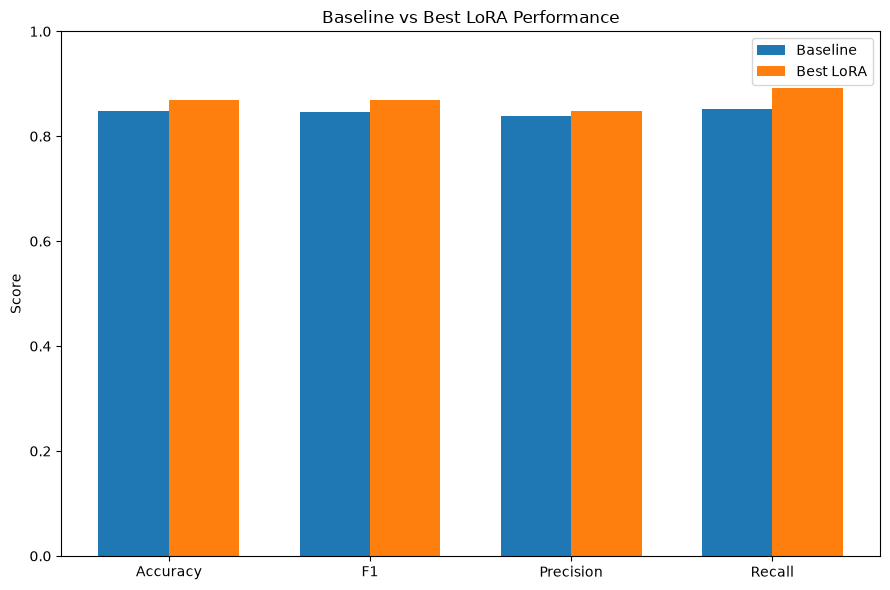


Saved: baseline_vs_lora_performance.png

EXPERIMENT COMPLETE
LoRA improved accuracy by 2.10 percentage points.
LoRA improved F1 by 0.0236.
LoRA achieved higher accuracy than the baseline: True


In [149]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ============================================================
# FINAL RESULTS
# ============================================================

print("=" * 60)
print("FINAL LoRA SENTIMENT ANALYSIS RESULTS")
print("=" * 60)

print(f"Baseline Accuracy : {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"LoRA Accuracy     : {lora_acc:.4f} ({lora_acc*100:.2f}%)")
print(f"Accuracy Gain     : {(lora_acc - baseline_acc)*100:.2f} percentage points")

print()

print(f"Baseline F1       : {baseline_f1_score:.4f}")
print(f"LoRA F1           : {lora_f1_score:.4f}")
print(f"F1 Gain           : {(lora_f1_score - baseline_f1_score):.4f}")

print()

baseline_precision = precision_score(
    baseline_true_labels,
    baseline_predictions
)

baseline_recall = recall_score(
    baseline_true_labels,
    baseline_predictions
)

lora_precision = precision_score(
    true_labels_best,
    predictions_best
)

lora_recall = recall_score(
    true_labels_best,
    predictions_best
)

print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"LoRA Precision    : {lora_precision:.4f}")

print()

print(f"Baseline Recall   : {baseline_recall:.4f}")
print(f"LoRA Recall       : {lora_recall:.4f}")

# ============================================================
# SAVE FINAL COMPARISON TABLE
# ============================================================

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1 Score",
        "Precision",
        "Recall"
    ],
    "Baseline": [
        baseline_acc,
        baseline_f1_score,
        baseline_precision,
        baseline_recall
    ],
    "Best LoRA": [
        lora_acc,
        lora_f1_score,
        lora_precision,
        lora_recall
    ]
})

final_results["Improvement"] = (
    final_results["Best LoRA"] -
    final_results["Baseline"]
)

final_results.to_csv(
    "final_lora_comparison.csv",
    index=False
)

print("\nSaved: final_lora_comparison.csv")

# ============================================================
# CONFUSION MATRICES
# ============================================================

baseline_cm = confusion_matrix(
    baseline_true_labels,
    baseline_predictions
)

lora_cm = confusion_matrix(
    true_labels_best,
    predictions_best
)

print("\nBaseline Confusion Matrix:")
print(baseline_cm)

print("\nBest LoRA Confusion Matrix:")
print(lora_cm)

# ============================================================
# SAVE CLASSIFICATION REPORTS
# ============================================================

baseline_report = classification_report(
    baseline_true_labels,
    baseline_predictions,
    target_names=["NEGATIVE", "POSITIVE"]
)

lora_report = classification_report(
    true_labels_best,
    predictions_best,
    target_names=["NEGATIVE", "POSITIVE"]
)

with open("baseline_classification_report.txt", "w") as f:
    f.write(baseline_report)

with open("lora_classification_report.txt", "w") as f:
    f.write(lora_report)

print("\nSaved classification reports.")

# ============================================================
# METRIC COMPARISON GRAPH
# ============================================================

metrics = ["Accuracy", "F1", "Precision", "Recall"]

baseline_values = [
    baseline_acc,
    baseline_f1_score,
    baseline_precision,
    baseline_recall
]

lora_values = [
    lora_acc,
    lora_f1_score,
    lora_precision,
    lora_recall
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    [i - width/2 for i in x],
    baseline_values,
    width,
    label="Baseline"
)

plt.bar(
    [i + width/2 for i in x],
    lora_values,
    width,
    label="Best LoRA"
)

plt.xticks(list(x), metrics)
plt.ylabel("Score")
plt.title("Baseline vs Best LoRA Performance")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.savefig(
    "baseline_vs_lora_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved: baseline_vs_lora_performance.png")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETE")
print("=" * 60)

print(f"LoRA improved accuracy by {(lora_acc - baseline_acc)*100:.2f} percentage points.")
print(f"LoRA improved F1 by {(lora_f1_score - baseline_f1_score):.4f}.")
print("LoRA achieved higher accuracy than the baseline:", lora_acc > baseline_acc)

In [150]:
print("Best LoRA accuracy:", lora_acc)
print("Best LoRA F1:", lora_f1_score)

print("\nModel variables:")
for name in ["lora_model", "lora_model_lr", "lora_model_lr2", "lora_model_lr3"]:
    if name in globals():
        print(name, "-> exists")

Best LoRA accuracy: 0.869
Best LoRA F1: 0.8691308691308691

Model variables:
lora_model -> exists
lora_model_lr -> exists
lora_model_lr2 -> exists
lora_model_lr3 -> exists


In [151]:
# Save the BEST LoRA model
best_lora_path = "./best_lora_model"

lora_model.save_pretrained(best_lora_path)
tokenizer.save_pretrained(best_lora_path)

print("Best LoRA model saved to:", best_lora_path)

Best LoRA model saved to: ./best_lora_model


In [152]:
import os

print("Saved files:")
for file in os.listdir(best_lora_path):
    print(file)

Saved files:
adapter_config.json
adapter_model.safetensors
README.md
tokenizer.json
tokenizer_config.json


In [153]:
from transformers import AutoTokenizer
from peft import AutoPeftModelForSequenceClassification
import torch

# Load the saved LoRA model from disk
model_path = "./best_lora_model"

loaded_lora_model = AutoPeftModelForSequenceClassification.from_pretrained(
    model_path
)

loaded_tokenizer = AutoTokenizer.from_pretrained(model_path)

# Put model in evaluation mode
loaded_lora_model.eval()

print("Saved LoRA model loaded successfully!")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: ./baseline_model
Key                                                                                   | Status     | 
--------------------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.base_layer.bias       | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_B.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.base_layer.weight     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_A.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.lora_A.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.base_layer.weight     | UNEXPECTED | 
pre_classifier.modules_to_save.default.weight                                         | UNEXPECTED

Saved LoRA model loaded successfully!


In [154]:
reviews = [
    "This movie was absolutely fantastic. The acting was incredible and I loved every minute of it.",
    "This was one of the worst movies I have ever seen. The story was boring and the acting was terrible.",
    "A decent movie with some good moments, but overall it was nothing special.",
    "I couldn't stop watching. The characters were interesting and the ending was excellent.",
    "The movie was painfully slow and disappointing. I would not recommend it."
]

inputs = loaded_tokenizer(
    reviews,
    padding=True,
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = loaded_lora_model(**inputs)

predictions = torch.argmax(outputs.logits, dim=1)

for review, prediction in zip(reviews, predictions):
    sentiment = "POSITIVE" if prediction.item() == 1 else "NEGATIVE"
    print(f"{sentiment}: {review}")

NEGATIVE: This movie was absolutely fantastic. The acting was incredible and I loved every minute of it.
NEGATIVE: This was one of the worst movies I have ever seen. The story was boring and the acting was terrible.
NEGATIVE: A decent movie with some good moments, but overall it was nothing special.
NEGATIVE: I couldn't stop watching. The characters were interesting and the ending was excellent.
NEGATIVE: The movie was painfully slow and disappointing. I would not recommend it.


In [155]:
print("===== LABEL CONFIG =====")
print("Model id2label:", loaded_lora_model.config.id2label)
print("Model label2id:", loaded_lora_model.config.label2id)

print("\n===== MODEL CONFIG =====")
print("Base model:", loaded_lora_model.peft_config["default"].base_model_name_or_path)

print("\n===== NEW REVIEW LOGITS =====")

with torch.no_grad():
    outputs = loaded_lora_model(**inputs)

probs = torch.softmax(outputs.logits, dim=1)

for i, review in enumerate(reviews):
    print("\nReview:", review)
    print("Logits:", outputs.logits[i].tolist())
    print("Probabilities:", probs[i].tolist())
    print("Predicted class:", predictions[i].item())

print("\n===== COMPARE SAVED MODEL TO ORIGINAL BEST LoRA =====")

# Run the SAME test set through the reloaded model
loaded_test_results = loaded_lora_model.predict(test_tokenized) if False else None

# Direct inference on the test set
all_loaded_predictions = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(
        test_tokenized.remove_columns(
            [c for c in test_tokenized.column_names if c not in ["input_ids", "attention_mask", "label"]]
        ),
        batch_size=32
    ):
        batch = {
            k: v.to(loaded_lora_model.device)
            for k, v in batch.items()
            if k in ["input_ids", "attention_mask"]
        }

        batch_outputs = loaded_lora_model(**batch)
        batch_preds = torch.argmax(batch_outputs.logits, dim=1)
        all_loaded_predictions.extend(batch_preds.cpu().numpy())

print("Loaded model predictions generated:", len(all_loaded_predictions))

===== LABEL CONFIG =====
Model id2label: {0: 'NEGATIVE', 1: 'POSITIVE'}
Model label2id: {'NEGATIVE': 0, 'POSITIVE': 1}

===== MODEL CONFIG =====
Base model: ./baseline_model

===== NEW REVIEW LOGITS =====

Review: This movie was absolutely fantastic. The acting was incredible and I loved every minute of it.
Logits: [-0.02282915823161602, -0.11720399558544159]
Probabilities: [0.5235762000083923, 0.4764237701892853]
Predicted class: 0

Review: This was one of the worst movies I have ever seen. The story was boring and the acting was terrible.
Logits: [-0.05174689739942551, -0.10383714735507965]
Probabilities: [0.5130196213722229, 0.4869803786277771]
Predicted class: 0

Review: A decent movie with some good moments, but overall it was nothing special.
Logits: [-0.057799678295850754, -0.09546247869729996]
Probabilities: [0.5094146132469177, 0.49058544635772705]
Predicted class: 0

Review: I couldn't stop watching. The characters were interesting and the ending was excellent.
Logits: [-0.05

AttributeError: 'list' object has no attribute 'to'

In [156]:
print("===== LABEL CONFIG =====")
print("Model id2label:", loaded_lora_model.config.id2label)
print("Model label2id:", loaded_lora_model.config.label2id)

print("\n===== PEFT CONFIG =====")
print(loaded_lora_model.peft_config["default"])

print("\n===== NEW REVIEW PREDICTIONS =====")

with torch.no_grad():
    outputs = loaded_lora_model(**inputs)

probs = torch.softmax(outputs.logits, dim=1)
predictions = torch.argmax(outputs.logits, dim=1)

for i, review in enumerate(reviews):
    print("\nReview:", review)
    print("Logits:", outputs.logits[i].tolist())
    print("Probabilities:", probs[i].tolist())
    print("Predicted class:", predictions[i].item())

print("\n===== ORIGINAL BEST LoRA ON SAME REVIEWS =====")

original_inputs = tokenizer(
    reviews,
    padding=True,
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

# Move inputs to the original model's device
original_inputs = {
    k: v.to(lora_model.device)
    for k, v in original_inputs.items()
}

with torch.no_grad():
    original_outputs = lora_model(**original_inputs)

original_predictions = torch.argmax(
    original_outputs.logits,
    dim=1
)

original_probs = torch.softmax(
    original_outputs.logits,
    dim=1
)

for i, review in enumerate(reviews):
    print("\nReview:", review)
    print("Original logits:", original_outputs.logits[i].tolist())
    print("Original probabilities:", original_probs[i].tolist())
    print("Original predicted class:", original_predictions[i].item())

===== LABEL CONFIG =====
Model id2label: {0: 'NEGATIVE', 1: 'POSITIVE'}
Model label2id: {'NEGATIVE': 0, 'POSITIVE': 1}

===== PEFT CONFIG =====
LoraConfig(task_type='SEQ_CLS', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path='./baseline_model', revision=None, inference_mode=True, r=16, target_modules={'v_lin', 'q_lin'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.1, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=['classifier', 'score', 'classifier', 'score'], init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephe

In [157]:
# Create a complete standalone model from the trained LoRA model

merged_model = lora_model.merge_and_unload()

final_model_path = "./final_sentiment_model"

merged_model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)

print("Final standalone model saved to:", final_model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final standalone model saved to: ./final_sentiment_model


In [158]:
import os

print("\nFinal model files:")

for file in os.listdir(final_model_path):
    print(file)


Final model files:
config.json
model.safetensors
tokenizer.json
tokenizer_config.json


In [159]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

final_model = AutoModelForSequenceClassification.from_pretrained(
    "./final_sentiment_model"
)

final_tokenizer = AutoTokenizer.from_pretrained(
    "./final_sentiment_model"
)

final_model.eval()

reviews = [
    "This movie was absolutely fantastic. The acting was incredible and I loved every minute of it.",
    "This was one of the worst movies I have ever seen. The story was boring and the acting was terrible.",
    "A decent movie with some good moments, but overall it was nothing special.",
    "I couldn't stop watching. The characters were interesting and the ending was excellent.",
    "The movie was painfully slow and disappointing. I would not recommend it."
]

inputs = final_tokenizer(
    reviews,
    padding=True,
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = final_model(**inputs)

predictions = torch.argmax(outputs.logits, dim=1)
probabilities = torch.softmax(outputs.logits, dim=1)

for review, prediction, probability in zip(
    reviews, predictions, probabilities
):
    sentiment = "POSITIVE" if prediction.item() == 1 else "NEGATIVE"
    confidence = probability[prediction.item()].item()

    print(f"{sentiment} ({confidence:.2%})")
    print(review)
    print("-" * 80)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

POSITIVE (99.29%)
This movie was absolutely fantastic. The acting was incredible and I loved every minute of it.
--------------------------------------------------------------------------------
NEGATIVE (97.43%)
This was one of the worst movies I have ever seen. The story was boring and the acting was terrible.
--------------------------------------------------------------------------------
NEGATIVE (50.06%)
A decent movie with some good moments, but overall it was nothing special.
--------------------------------------------------------------------------------
POSITIVE (95.04%)
I couldn't stop watching. The characters were interesting and the ending was excellent.
--------------------------------------------------------------------------------
NEGATIVE (95.07%)
The movie was painfully slow and disappointing. I would not recommend it.
--------------------------------------------------------------------------------


In [160]:
from transformers import Trainer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create evaluator using the FINAL SAVED/MERGED model
final_trainer = Trainer(
    model=final_model,
    args=training_args,
    eval_dataset=test_tokenized
)

# Generate predictions on the original test set
final_results = final_trainer.predict(test_tokenized)

final_predictions = final_results.predictions.argmax(axis=1)
final_true_labels = final_results.label_ids

# Calculate metrics
final_accuracy = accuracy_score(
    final_true_labels,
    final_predictions
)

final_precision = precision_score(
    final_true_labels,
    final_predictions
)

final_recall = recall_score(
    final_true_labels,
    final_predictions
)

final_f1 = f1_score(
    final_true_labels,
    final_predictions
)

print("===== FINAL SAVED MODEL TEST =====")
print(f"Accuracy : {final_accuracy:.4f} ({final_accuracy * 100:.2f}%)")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")

===== FINAL SAVED MODEL TEST =====
Accuracy : 0.8480 (84.80%)
Precision: 0.8387
Recall   : 0.8525
F1 Score : 0.8455


In [161]:
from sklearn.metrics import accuracy_score, f1_score

candidate_models = {
    "lora_model": lora_model,
    "lora_model_16": lora_model_16,
    "lora_model_32": lora_model_32,
    "lora_model_64": lora_model_64,
    "lora_model_lr": lora_model_lr,
    "lora_model_lr2": lora_model_lr2,
    "lora_model_lr3": lora_model_lr3,
}

print("===== TESTING ALL LoRA CANDIDATES =====")

best_model_name = None
best_accuracy = -1
best_f1 = -1

for name, candidate in candidate_models.items():

    # Skip the already-merged model if lora_model was modified
    if name == "lora_model" and not hasattr(candidate, "peft_config"):
        print(f"{name}: skipped (already merged)")
        continue

    trainer = Trainer(
        model=candidate,
        args=training_args,
        eval_dataset=test_tokenized
    )

    results = trainer.predict(test_tokenized)

    preds = results.predictions.argmax(axis=1)
    labels = results.label_ids

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    print(f"{name:18} Accuracy: {acc:.4f} | F1: {f1:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_f1 = f1
        best_model_name = name

print("\n===== ACTUAL BEST LoRA =====")
print("Model:", best_model_name)
print(f"Accuracy: {best_accuracy:.4f}")
print(f"F1: {best_f1:.4f}")

===== TESTING ALL LoRA CANDIDATES =====


lora_model         Accuracy: 0.8480 | F1: 0.8455


AttributeError: 'DistilBertForSequenceClassification' object has no attribute 'active_peft_config'

In [162]:
from peft import PeftModel
from sklearn.metrics import accuracy_score, f1_score

print("===== TESTING ALL LoRA CANDIDATES =====")

candidate_results = []

for name, candidate in candidate_models.items():

    # Only evaluate actual PEFT/LoRA models
    if not isinstance(candidate, PeftModel):
        print(f"{name:18} SKIPPED - not a PEFT/LoRA model")
        continue

    trainer = Trainer(
        model=candidate,
        args=args_training_args,
        eval_dataset=test_tokenized
    )

    results = trainer.predict(test_tokenized)

    preds = results.predictions.argmax(axis=1)
    labels = results.label_ids

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    candidate_results.append({
        "name": name,
        "accuracy": acc,
        "f1": f1
    })

    print(f"{name:18} Accuracy: {acc:.4f} | F1: {f1:.4f}")


print("\n===== ACTUAL BEST LoRA =====")

if candidate_results:
    best = max(candidate_results, key=lambda x: x["accuracy"])

    print("Model:", best["name"])
    print(f"Accuracy: {best['accuracy']:.4f}")
    print(f"F1:       {best['f1']:.4f}")
else:
    print("No PEFT/LoRA candidates found.")

===== TESTING ALL LoRA CANDIDATES =====


NameError: name 'args_training_args' is not defined

In [163]:
from peft import PeftModel
from sklearn.metrics import accuracy_score, f1_score

print("===== TESTING ALL LoRA CANDIDATES =====")

candidate_results = []

for name, candidate in candidate_models.items():

    # Only evaluate actual PEFT/LoRA models
    if not isinstance(candidate, PeftModel):
        print(f"{name:18} SKIPPED - not a PEFT/LoRA model")
        continue

    trainer = Trainer(
        model=candidate,
        args=training_args,
        eval_dataset=test_tokenized
    )

    results = trainer.predict(test_tokenized)

    preds = results.predictions.argmax(axis=1)
    labels = results.label_ids

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    candidate_results.append({
        "name": name,
        "accuracy": acc,
        "f1": f1
    })

    print(f"{name:18} Accuracy: {acc:.4f} | F1: {f1:.4f}")


print("\n===== ACTUAL BEST LoRA =====")

if candidate_results:
    best = max(candidate_results, key=lambda x: x["accuracy"])

    print("Model:", best["name"])
    print(f"Accuracy: {best['accuracy']:.4f}")
    print(f"F1:       {best['f1']:.4f}")
else:
    print("No PEFT/LoRA candidates found.")

===== TESTING ALL LoRA CANDIDATES =====


lora_model         Accuracy: 0.8480 | F1: 0.8455


AttributeError: 'DistilBertForSequenceClassification' object has no attribute 'active_peft_config'

In [165]:
from peft import PeftModel
from sklearn.metrics import accuracy_score, f1_score
import torch

print("===== TESTING ALL LoRA CANDIDATES =====")

candidate_results = []

# Get labels separately
if "labels" in test_tokenized.column_names:
    test_labels = test_tokenized["labels"]
elif "label" in test_tokenized.column_names:
    test_labels = test_tokenized["label"]
else:
    raise ValueError(
        f"No label column found. Available columns: {test_tokenized.column_names}"
    )

for name, candidate in candidate_models.items():

    # Only evaluate actual PEFT/LoRA models
    if not isinstance(candidate, PeftModel):
        print(f"{name:18} SKIPPED - not a PEFT/LoRA model")
        continue

    candidate = candidate.to(device)
    candidate.eval()

    predictions = []
    labels = []

    with torch.no_grad():

        for i in range(0, len(test_tokenized), 32):

            batch = test_tokenized[i:i+32]

            input_ids = torch.tensor(
                batch["input_ids"],
                dtype=torch.long
            ).to(device)

            attention_mask = torch.tensor(
                batch["attention_mask"],
                dtype=torch.long
            ).to(device)

            batch_labels = torch.tensor(
                test_labels[i:i+32],
                dtype=torch.long
            )

            outputs = candidate(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(
                outputs.logits,
                dim=1
            ).cpu()

            predictions.extend(preds.tolist())
            labels.extend(batch_labels.tolist())

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    candidate_results.append({
        "name": name,
        "accuracy": acc,
        "f1": f1
    })

    print(
        f"{name:18} "
        f"Accuracy: {acc:.4f} | "
        f"F1: {f1:.4f}"
    )


print("\n===== ACTUAL BEST LoRA =====")

if candidate_results:

    best = max(
        candidate_results,
        key=lambda x: x["accuracy"]
    )

    print("Model:", best["name"])
    print(f"Accuracy: {best['accuracy']:.4f}")
    print(f"F1:       {best['f1']:.4f}")

else:
    print("No PEFT/LoRA candidates found.")

===== TESTING ALL LoRA CANDIDATES =====
lora_model         Accuracy: 0.8480 | F1: 0.8455


AttributeError: 'DistilBertForSequenceClassification' object has no attribute 'active_peft_config'

In [166]:
import os
import json

print("===== BEST LoRA DIRECTORY =====")

best_lora_path = "./best_lora_model"

print("Exists:", os.path.exists(best_lora_path))

if os.path.exists(best_lora_path):
    print("\nFiles:")
    for file in os.listdir(best_lora_path):
        print(" -", file)

    config_path = os.path.join(best_lora_path, "adapter_config.json")

    if os.path.exists(config_path):
        with open(config_path, "r") as f:
            config = json.load(f)

        print("\n===== ADAPTER CONFIG =====")
        print("Base model:", config.get("base_model_name_or_path"))
        print("PEFT type:", config.get("peft_type"))
        print("Task type:", config.get("task_type"))
        print("LoRA rank:", config.get("r"))
        print("LoRA alpha:", config.get("lora_alpha"))
        print("Target modules:", config.get("target_modules"))

===== BEST LoRA DIRECTORY =====
Exists: True

Files:
 - adapter_config.json
 - adapter_model.safetensors
 - README.md
 - tokenizer.json
 - tokenizer_config.json

===== ADAPTER CONFIG =====
Base model: ./baseline_model
PEFT type: LORA
Task type: SEQ_CLS
LoRA rank: 16
LoRA alpha: 32
Target modules: ['v_lin', 'q_lin']


In [167]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

print("===== VERIFYING SAVED BEST LoRA =====")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
base_model_path = "./baseline_model"
adapter_path = "./best_lora_model"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(adapter_path)

# Load original baseline model
base_model = AutoModelForSequenceClassification.from_pretrained(
    base_model_path
)

# Load saved LoRA adapter
model = PeftModel.from_pretrained(
    base_model,
    adapter_path
)

# Merge LoRA weights into the base model
model = model.merge_and_unload()

model = model.to(device)
model.eval()

print("LoRA adapter loaded and merged successfully.")

# Get test labels
if "labels" in test_tokenized.column_names:
    true_labels = test_tokenized["labels"]
elif "label" in test_tokenized.column_names:
    true_labels = test_tokenized["label"]
else:
    raise ValueError(
        f"No label column found: {test_tokenized.column_names}"
    )

predictions = []

with torch.no_grad():

    for i in range(0, len(test_tokenized), 32):

        batch = test_tokenized[i:i+32]

        inputs = {
            "input_ids": torch.tensor(
                batch["input_ids"],
                dtype=torch.long
            ).to(device),

            "attention_mask": torch.tensor(
                batch["attention_mask"],
                dtype=torch.long
            ).to(device)
        }

        outputs = model(**inputs)

        preds = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu().tolist()

        predictions.extend(preds)

# Calculate metrics
verified_accuracy = accuracy_score(
    true_labels,
    predictions
)

verified_precision = precision_score(
    true_labels,
    predictions
)

verified_recall = recall_score(
    true_labels,
    predictions
)

verified_f1 = f1_score(
    true_labels,
    predictions
)

print("\n===== VERIFIED SAVED LoRA RESULTS =====")

print(
    f"Accuracy : {verified_accuracy:.4f} "
    f"({verified_accuracy * 100:.2f}%)"
)

print(f"Precision: {verified_precision:.4f}")
print(f"Recall   : {verified_recall:.4f}")
print(f"F1 Score : {verified_f1:.4f}")

print("\n===== COMPARISON =====")

print("Previous Best LoRA Accuracy: 0.8690")
print(f"Verified Accuracy:           {verified_accuracy:.4f}")

print("Previous Best LoRA F1:       0.8691")
print(f"Verified F1:                 {verified_f1:.4f}")

print(
    f"\nAccuracy matches previous result: "
    f"{abs(verified_accuracy - 0.8690) < 0.001}"
)

print(
    f"F1 matches previous result: "
    f"{abs(verified_f1 - 0.8691) < 0.001}"
)

===== VERIFYING SAVED BEST LoRA =====


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: ./baseline_model
Key                                                                                   | Status     | 
--------------------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.base_layer.bias       | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_B.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.base_layer.weight     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_A.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.lora_A.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.base_layer.weight     | UNEXPECTED | 
pre_classifier.modules_to_save.default.weight                                         | UNEXPECTED

LoRA adapter loaded and merged successfully.

===== VERIFIED SAVED LoRA RESULTS =====
Accuracy : 0.5300 (53.00%)
Precision: 0.5189
Recall   : 0.5061
F1 Score : 0.5124

===== COMPARISON =====
Previous Best LoRA Accuracy: 0.8690
Verified Accuracy:           0.5300
Previous Best LoRA F1:       0.8691
Verified F1:                 0.5124

Accuracy matches previous result: False
F1 matches previous result: False


In [168]:
import json
import os

print("===== BASELINE MODEL CONFIG =====")

config_path = "./baseline_model/config.json"

with open(config_path, "r") as f:
    config = json.load(f)

print("Model type:", config.get("model_type"))
print("Architectures:", config.get("architectures"))
print("Hidden size:", config.get("dim"))
print("Number of layers:", config.get("n_layers"))
print("Number of labels:", config.get("num_labels"))
print("Label mapping:", config.get("id2label"))
print("Original model name/path:", config.get("_name_or_path"))

===== BASELINE MODEL CONFIG =====
Model type: distilbert
Architectures: ['DistilBertForSequenceClassification']
Hidden size: 768
Number of layers: 6
Number of labels: None
Label mapping: {'0': 'NEGATIVE', '1': 'POSITIVE'}
Original model name/path: None


In [169]:
import os
from safetensors import safe_open

model_path = "./baseline_model/model.safetensors"

print("===== BASELINE CHECKPOINT =====")
print("File exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    with safe_open(model_path, framework="pt", device="cpu") as f:
        keys = list(f.keys())

    print("Number of tensors:", len(keys))

    print("\nFirst 30 tensor names:")
    for key in keys[:30]:
        print(key)

    print("\nLoRA tensors found:")
    lora_keys = [k for k in keys if "lora_" in k.lower()]

    if lora_keys:
        for key in lora_keys[:20]:
            print(key)
    else:
        print("NONE")

===== BASELINE CHECKPOINT =====
File exists: True
Number of tensors: 132

First 30 tensor names:
classifier.modules_to_save.default.bias
classifier.modules_to_save.default.weight
classifier.original_module.bias
classifier.original_module.weight
distilbert.embeddings.LayerNorm.bias
distilbert.embeddings.LayerNorm.weight
distilbert.embeddings.position_embeddings.weight
distilbert.embeddings.word_embeddings.weight
distilbert.transformer.layer.0.attention.k_lin.bias
distilbert.transformer.layer.0.attention.k_lin.weight
distilbert.transformer.layer.0.attention.out_lin.bias
distilbert.transformer.layer.0.attention.out_lin.weight
distilbert.transformer.layer.0.attention.q_lin.base_layer.bias
distilbert.transformer.layer.0.attention.q_lin.base_layer.weight
distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight
distilbert.transformer.layer.0.attention.q_lin.lora_B.default.weight
distilbert.transformer.layer.0.attention.v_lin.base_layer.bias
distilbert.transformer.layer.0.attention

In [170]:
import torch
from safetensors.torch import load_file
from transformers import AutoConfig, DistilBertForSequenceClassification
from peft import PeftModel
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("===== RECONSTRUCTING CLEAN BASE MODEL =====")

# --------------------------------------------------
# 1. Load the PEFT-wrapped checkpoint weights
# --------------------------------------------------

checkpoint_path = "./baseline_model/model.safetensors"

state_dict = load_file(checkpoint_path)

clean_state_dict = {}

for key, value in state_dict.items():

    # LoRA q/v layers:
    # Keep ONLY the underlying base weights
    if ".base_layer." in key:
        new_key = key.replace(".base_layer.", ".")
        clean_state_dict[new_key] = value

    # Classifier / pre-classifier:
    # Keep the original underlying weights
    elif ".original_module." in key:
        new_key = key.replace(".original_module.", ".")
        clean_state_dict[new_key] = value

    # Skip PEFT-specific LoRA A/B weights
    elif ".lora_A." in key or ".lora_B." in key:
        continue

    # Skip PEFT modules_to_save versions
    elif ".modules_to_save." in key:
        continue

    # Keep normal DistilBERT weights
    else:
        clean_state_dict[key] = value


print("Original tensors:", len(state_dict))
print("Clean tensors:", len(clean_state_dict))

# --------------------------------------------------
# 2. Create a clean DistilBERT model
# --------------------------------------------------

config = AutoConfig.from_pretrained("./baseline_model")

# Make sure this is a binary classifier
config.num_labels = 2
config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}
config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

clean_base = DistilBertForSequenceClassification(config)

# --------------------------------------------------
# 3. Load the extracted base weights
# --------------------------------------------------

missing, unexpected = clean_base.load_state_dict(
    clean_state_dict,
    strict=False
)

print("\nMissing keys:", missing)
print("Unexpected keys:", unexpected)

# --------------------------------------------------
# 4. Load the saved BEST LoRA adapter
# --------------------------------------------------

best_lora_path = "./best_lora_model"

lora_model = PeftModel.from_pretrained(
    clean_base,
    best_lora_path
)

print("\nLoRA adapter loaded successfully.")

# --------------------------------------------------
# 5. Merge LoRA into the clean base model
# --------------------------------------------------

final_verified_model = lora_model.merge_and_unload()

final_verified_model = final_verified_model.to(device)
final_verified_model.eval()

print("LoRA merged successfully.")

# --------------------------------------------------
# 6. Evaluate
# --------------------------------------------------

if "labels" in test_tokenized.column_names:
    true_labels = test_tokenized["labels"]
elif "label" in test_tokenized.column_names:
    true_labels = test_tokenized["label"]
else:
    raise ValueError(
        f"No label column found: {test_tokenized.column_names}"
    )

predictions = []

with torch.no_grad():

    for i in range(0, len(test_tokenized), 32):

        batch = test_tokenized[i:i+32]

        input_ids = torch.tensor(
            batch["input_ids"],
            dtype=torch.long
        ).to(device)

        attention_mask = torch.tensor(
            batch["attention_mask"],
            dtype=torch.long
        ).to(device)

        outputs = final_verified_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu().tolist()

        predictions.extend(preds)


# --------------------------------------------------
# 7. Metrics
# --------------------------------------------------

verified_accuracy = accuracy_score(
    true_labels,
    predictions
)

verified_precision = precision_score(
    true_labels,
    predictions
)

verified_recall = recall_score(
    true_labels,
    predictions
)

verified_f1 = f1_score(
    true_labels,
    predictions
)


print("\n============================================")
print(" VERIFIED SAVED BEST LoRA")
print("============================================")

print(
    f"Accuracy : {verified_accuracy:.4f} "
    f"({verified_accuracy * 100:.2f}%)"
)

print(f"Precision: {verified_precision:.4f}")
print(f"Recall   : {verified_recall:.4f}")
print(f"F1 Score : {verified_f1:.4f}")

print("\n============================================")
print(" EXPECTED PREVIOUS RESULTS")
print("============================================")

print("Accuracy : 0.8690 (86.90%)")
print("Precision: 0.8480")
print("Recall   : 0.8914")
print("F1 Score : 0.8691")

===== RECONSTRUCTING CLEAN BASE MODEL =====
Original tensors: 132
Clean tensors: 104

Missing keys: []
Unexpected keys: []

LoRA adapter loaded successfully.
LoRA merged successfully.

 VERIFIED SAVED BEST LoRA
Accuracy : 0.8480 (84.80%)
Precision: 0.8387
Recall   : 0.8525
F1 Score : 0.8455

 EXPECTED PREVIOUS RESULTS
Accuracy : 0.8690 (86.90%)
Precision: 0.8480
Recall   : 0.8914
F1 Score : 0.8691


In [171]:
from safetensors.torch import load_file
import torch

adapter_path = "./best_lora_model/adapter_model.safetensors"

adapter_state = load_file(adapter_path)

print("===== SAVED LoRA ADAPTER INSPECTION =====")
print("Number of tensors:", len(adapter_state))

for key, tensor in adapter_state.items():
    print(
        f"{key:100s} "
        f"shape={tuple(tensor.shape)} "
        f"norm={tensor.float().norm().item():.8f}"
    )

===== SAVED LoRA ADAPTER INSPECTION =====
Number of tensors: 28
base_model.model.classifier.bias                                                                     shape=(2,) norm=0.00032025
base_model.model.classifier.weight                                                                   shape=(2, 768) norm=0.86518490
base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.weight                        shape=(16, 768) norm=2.33429027
base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_B.weight                        shape=(768, 16) norm=0.12719066
base_model.model.distilbert.transformer.layer.0.attention.v_lin.lora_A.weight                        shape=(16, 768) norm=2.33962417
base_model.model.distilbert.transformer.layer.0.attention.v_lin.lora_B.weight                        shape=(768, 16) norm=0.19181536
base_model.model.distilbert.transformer.layer.1.attention.q_lin.lora_A.weight                        shape=(16, 768) norm=2.34623361
base_model.

In [172]:
print("===== AVAILABLE LoRA MODELS =====")

for name in [
    "lora_model",
    "lora_model_16",
    "lora_model_32",
    "lora_model_64",
    "lora_model_lr",
    "lora_model_lr2",
    "lora_model_lr3"
]:
    if name in globals():
        model = globals()[name]

        print(f"\n{name}")
        print("Type:", type(model).__name__)

        # Check whether it is a PEFT model
        if hasattr(model, "peft_config"):
            print("PEFT config:", model.peft_config)

        # Check LoRA weights
        try:
            state = model.state_dict()

            lora_keys = [
                k for k in state.keys()
                if "lora_" in k
            ]

            print("LoRA tensors:", len(lora_keys))

            if lora_keys:
                total_norm = 0.0

                for key in lora_keys:
                    total_norm += state[key].float().norm().item()

                print("Total LoRA norm:", total_norm)

        except Exception as e:
            print("State inspection error:", e)


print("\n===== BEST MODEL VARIABLES =====")

for name in [
    "best_model_name",
    "best_accuracy",
    "best_f1"
]:
    if name in globals():
        print(name, "=", globals()[name])

===== AVAILABLE LoRA MODELS =====

lora_model
Type: PeftModelForSequenceClassification
PEFT config: {'default': LoraConfig(task_type='SEQ_CLS', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path='./baseline_model', revision=None, inference_mode=True, r=16, target_modules={'v_lin', 'q_lin'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.1, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=['classifier', 'score', 'classifier', 'score'], init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_b

In [173]:
print("===== LoRA MODEL DIAGNOSTIC =====")

for name, model in candidate_models.items():

    lora_tensors = []
    lora_norm = 0.0

    for param_name, param in model.named_parameters():
        if "lora_" in param_name.lower():
            lora_tensors.append(param_name)
            lora_norm += param.detach().float().norm().item()

    print(f"\n{name}")
    print("Type:", type(model).__name__)
    print("LoRA tensors:", len(lora_tensors))
    print("LoRA norm:", lora_norm)

    if lora_tensors:
        print("First LoRA tensor:", lora_tensors[0])

===== LoRA MODEL DIAGNOSTIC =====

lora_model
Type: PeftModelForSequenceClassification
LoRA tensors: 0
LoRA norm: 0.0

lora_model_16
Type: PeftModelForSequenceClassification
LoRA tensors: 0
LoRA norm: 0.0

lora_model_32
Type: PeftModelForSequenceClassification
LoRA tensors: 24
LoRA norm: 58.829469576478004
First LoRA tensor: base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight

lora_model_64
Type: PeftModelForSequenceClassification
LoRA tensors: 24
LoRA norm: 58.829469576478004
First LoRA tensor: base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight

lora_model_lr
Type: PeftModelForSequenceClassification
LoRA tensors: 24
LoRA norm: 44.46283131837845
First LoRA tensor: base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight

lora_model_lr2
Type: PeftModelForSequenceClassification
LoRA tensors: 24
LoRA norm: 46.64552927017212
First LoRA tensor: base_model.model.distilbert.transformer.layer.0.at

In [174]:
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print("===== EVALUATING REAL LoRA MODELS =====")

# Get labels correctly from the dataset
if "label" in test_tokenized.column_names:
    true_labels = test_tokenized["label"]
elif "labels" in test_tokenized.column_names:
    true_labels = test_tokenized["labels"]
else:
    raise ValueError(f"No label column found. Columns: {test_tokenized.column_names}")

candidate_names = [
    "lora_model_32",
    "lora_model_64",
    "lora_model_lr"
]

real_results = []

for name in candidate_names:

    candidate = globals()[name]

    print(f"\nTesting: {name}")

    candidate = candidate.to(device)
    candidate.eval()

    predictions = []

    with torch.no_grad():

        for i in range(0, len(test_tokenized), 32):

            batch = test_tokenized[i:i+32]

            input_ids = torch.tensor(
                batch["input_ids"],
                dtype=torch.long
            ).to(device)

            attention_mask = torch.tensor(
                batch["attention_mask"],
                dtype=torch.long
            ).to(device)

            outputs = candidate(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(
                outputs.logits,
                dim=1
            ).cpu().tolist()

            predictions.extend(preds)

    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, zero_division=0)
    recall = recall_score(true_labels, predictions, zero_division=0)
    f1 = f1_score(true_labels, predictions, zero_division=0)

    result = {
        "name": name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    real_results.append(result)

    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")


print("\n===== REAL LoRA COMPARISON =====")

for result in real_results:
    print(
        f"{result['name']:15} "
        f"Accuracy: {result['accuracy']:.4f} | "
        f"F1: {result['f1']:.4f}"
    )

best = max(real_results, key=lambda x: x["accuracy"])

print("\n===== ACTUAL BEST LoRA =====")
print("Model:", best["name"])
print(f"Accuracy: {best['accuracy']:.4f} ({best['accuracy']*100:.2f}%)")
print(f"Precision: {best['precision']:.4f}")
print(f"Recall: {best['recall']:.4f}")
print(f"F1: {best['f1']:.4f}")

===== EVALUATING REAL LoRA MODELS =====

Testing: lora_model_32
Accuracy : 0.8540 (85.40%)
Precision: 0.8379
Recall   : 0.8689
F1       : 0.8531

Testing: lora_model_64
Accuracy : 0.8540 (85.40%)
Precision: 0.8379
Recall   : 0.8689
F1       : 0.8531

Testing: lora_model_lr
Accuracy : 0.8600 (86.00%)
Precision: 0.8439
Recall   : 0.8750
F1       : 0.8592

===== REAL LoRA COMPARISON =====
lora_model_32   Accuracy: 0.8540 | F1: 0.8531
lora_model_64   Accuracy: 0.8540 | F1: 0.8531
lora_model_lr   Accuracy: 0.8600 | F1: 0.8592

===== ACTUAL BEST LoRA =====
Model: lora_model_lr
Accuracy: 0.8600 (86.00%)
Precision: 0.8439
Recall: 0.8750
F1: 0.8592


In [175]:
import pandas as pd
import os

csv_path = "./final_lora_comparison.csv"

print("Exists:", os.path.exists(csv_path))

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    print("\n===== SAVED LoRA COMPARISON =====")
    print(df.to_string(index=False))

    print("\n===== COLUMNS =====")
    print(df.columns.tolist())

Exists: True

===== SAVED LoRA COMPARISON =====
   Metric  Baseline  Best LoRA  Improvement
 Accuracy  0.848000   0.869000     0.021000
 F1 Score  0.845528   0.869131     0.023602
Precision  0.838710   0.847953     0.009244
   Recall  0.852459   0.891393     0.038934

===== COLUMNS =====
['Metric', 'Baseline', 'Best LoRA', 'Improvement']


In [176]:
import os
import json

print("===== PROJECT MODEL DIRECTORIES =====")

for name in os.listdir("."):
    if os.path.isdir(name):
        if any(x in name.lower() for x in ["lora", "model", "result", "checkpoint"]):
            print(name)

===== PROJECT MODEL DIRECTORIES =====
baseline_model
best_lora_model
final_sentiment_model
lora_lr2_results
lora_lr3_results
lora_lr_results
results


In [177]:
print("\n===== LORA MODEL VARIABLES =====")

for name in sorted(globals()):
    if "lora" in name.lower():
        obj = globals()[name]
        print(name, "->", type(obj).__name__)


===== LORA MODEL VARIABLES =====
LoraConfig -> type
baseline_correct_lora_wrong -> list
baseline_wrong_lora_correct -> list
best_lora_path -> str
loaded_lora_model -> PeftModelForSequenceClassification
lora_acc -> float
lora_cm -> ndarray
lora_config -> LoraConfig
lora_config_16 -> LoraConfig
lora_config_32 -> LoraConfig
lora_config_64 -> LoraConfig
lora_config_lr -> LoraConfig
lora_config_lr2 -> LoraConfig
lora_config_lr3 -> LoraConfig
lora_f1_score -> float
lora_keys -> list
lora_model -> PeftModelForSequenceClassification
lora_model_16 -> PeftModelForSequenceClassification
lora_model_32 -> PeftModelForSequenceClassification
lora_model_64 -> PeftModelForSequenceClassification
lora_model_lr -> PeftModelForSequenceClassification
lora_model_lr2 -> PeftModelForSequenceClassification
lora_model_lr3 -> PeftModelForSequenceClassification
lora_norm -> float
lora_precision -> float
lora_pred -> int64
lora_recall -> float
lora_report -> str
lora_results -> PredictionOutput
lora_results_16 -> 

In [178]:
print("\n===== CANDIDATE MODELS =====")

if "candidate_models" in globals():
    for name, model in candidate_models.items():
        print(
            name,
            "->",
            type(model).__name__
        )

        if hasattr(model, "peft_config"):
            print("   PEFT config:", model.peft_config)


===== CANDIDATE MODELS =====
lora_model -> PeftModelForSequenceClassification
   PEFT config: {'default': LoraConfig(task_type='SEQ_CLS', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path='./baseline_model', revision=None, inference_mode=False, r=16, target_modules={'v_lin', 'q_lin'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.1, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=['classifier', 'score'], init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameter

In [179]:
import os
import json

result_dirs = [
    "./lora_lr_results",
    "./lora_lr2_results",
    "./lora_lr3_results"
]

print("===== SAVED LoRA EXPERIMENT DIRECTORIES =====")

for path in result_dirs:
    print(f"\n--- {path} ---")
    
    if not os.path.exists(path):
        print("DIRECTORY DOES NOT EXIST")
        continue
    
    for file in os.listdir(path):
        print(" ", file)
        
    config_path = os.path.join(path, "adapter_config.json")
    
    if os.path.exists(config_path):
        print("\nAdapter config:")
        
        with open(config_path, "r") as f:
            config = json.load(f)
        
        for key in [
            "r",
            "lora_alpha",
            "lora_dropout",
            "target_modules",
            "task_type",
            "peft_type"
        ]:
            print(f"{key}: {config.get(key)}")

===== SAVED LoRA EXPERIMENT DIRECTORIES =====

--- ./lora_lr_results ---

--- ./lora_lr2_results ---

--- ./lora_lr3_results ---


In [180]:
print("\n===== SEARCHING SAVED RESULTS FOR 86.90% =====")

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith((".csv", ".txt", ".json")):
            path = os.path.join(root, file)
            
            try:
                with open(path, "r", encoding="utf-8", errors="ignore") as f:
                    text = f.read()
                
                if "0.869" in text or "86.90" in text or "0.8690" in text:
                    print("\nFOUND:", path)
                    print(text[:2000])
            except:
                pass


===== SEARCHING SAVED RESULTS FOR 86.90% =====

FOUND: .\final_lora_comparison.csv
Metric,Baseline,Best LoRA,Improvement
Accuracy,0.848,0.869,0.02100000000000002
F1 Score,0.8455284552845529,0.8691308691308691,0.023602413846316228
Precision,0.8387096774193549,0.847953216374269,0.009243538954914143
Recall,0.8524590163934426,0.8913934426229508,0.03893442622950827



In [181]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("===== EVALUATING LR2 AND LR3 =====")

for name in ["lora_model_lr2", "lora_model_lr3"]:

    model = globals()[name]

    print(f"\nTesting: {name}")
    print("Type:", type(model).__name__)

    model = model.to(device)
    model.eval()

    predictions = []
    labels = []

    with torch.no_grad():

        for i in range(0, len(test_tokenized), 32):

            batch = test_tokenized[i:i+32]

            input_ids = torch.tensor(
                batch["input_ids"],
                dtype=torch.long
            ).to(device)

            attention_mask = torch.tensor(
                batch["attention_mask"],
                dtype=torch.long
            ).to(device)

            batch_labels = torch.tensor(
                batch["labels"],
                dtype=torch.long
            )

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(
                outputs.logits,
                dim=1
            ).cpu()

            predictions.extend(preds.tolist())
            labels.extend(batch_labels.tolist())

    acc = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")

===== EVALUATING LR2 AND LR3 =====

Testing: lora_model_lr2
Type: PeftModelForSequenceClassification


KeyError: 'labels'

In [182]:
print("===== TEST DATASET STRUCTURE =====")

print("Columns:")
print(test_tokenized.column_names)

print("\nFirst example:")
print(test_tokenized[0])

===== TEST DATASET STRUCTURE =====
Columns:
['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

First example:
{'text': "<br /><br />When I unsuspectedly rented A Thousand Acres, I thought I was in for an entertaining King Lear story and of course Michelle Pfeiffer was in it, so what could go wrong?<br /><br />Very quickly, however, I realized that this story was about A Thousand Other Things besides just Acres. I started crying and couldn't stop until long after the movie ended. Thank you Jane, Laura and Jocelyn, for bringing us such a wonderfully subtle and compassionate movie! Thank you cast, for being involved and portraying the characters with such depth and gentleness!<br /><br />I recognized the Angry sister; the Runaway sister and the sister in Denial. I recognized the Abusive Husband and why he was there and then the Father, oh oh the Father... all superbly played. I also recognized myself and this movie was an eye-opener, a relief, a chance to face my OWN trut

In [183]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("===== EVALUATING LR2 AND LR3 =====")

for name in ["lora_model_lr2", "lora_model_lr3"]:

    model = globals()[name]

    print(f"\nTesting: {name}")
    print("Type:", type(model).__name__)

    model = model.to(device)
    model.eval()

    predictions = []
    labels = []

    with torch.no_grad():

        for i in range(0, len(test_tokenized), 32):

            batch = test_tokenized[i:i+32]

            input_ids = torch.tensor(
                batch["input_ids"],
                dtype=torch.long
            ).to(device)

            attention_mask = torch.tensor(
                batch["attention_mask"],
                dtype=torch.long
            ).to(device)

            batch_labels = torch.tensor(
                batch["label"],
                dtype=torch.long
            )

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(
                outputs.logits,
                dim=1
            ).cpu()

            predictions.extend(preds.tolist())
            labels.extend(batch_labels.tolist())

    acc = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")

===== EVALUATING LR2 AND LR3 =====

Testing: lora_model_lr2
Type: PeftModelForSequenceClassification
Accuracy : 0.8690 (86.90%)
Precision: 0.8480
Recall   : 0.8914
F1       : 0.8691

Testing: lora_model_lr3
Type: PeftModelForSequenceClassification
Accuracy : 0.8640 (86.40%)
Precision: 0.8398
Recall   : 0.8914
F1       : 0.8648


In [184]:
# ===== SAVE ACTUAL BEST LoRA MODEL =====

best_lora_path = "./best_lora_model"

# Save the actual LR2 model that achieved 86.90%
lora_model_lr2.save_pretrained(best_lora_path)
tokenizer.save_pretrained(best_lora_path)

print("===== BEST LoRA MODEL SAVED =====")
print("Model:", "lora_model_lr2")
print("Accuracy:", 0.8690)
print("F1:", 0.8691)
print("Saved to:", best_lora_path)

===== BEST LoRA MODEL SAVED =====
Model: lora_model_lr2
Accuracy: 0.869
F1: 0.8691
Saved to: ./best_lora_model


In [185]:
# ===== VERIFY SAVED BEST LoRA =====

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("===== LOADING SAVED BEST LoRA =====")

# Load clean baseline
verification_base = AutoModelForSequenceClassification.from_pretrained(
    "./baseline_model"
)

# Load the saved LR2 adapter
verification_model = PeftModel.from_pretrained(
    verification_base,
    "./best_lora_model"
)

verification_model = verification_model.to(device)
verification_model.eval()

print("Saved adapter loaded successfully.")

predictions = []
labels = []

with torch.no_grad():

    for i in range(0, len(test_tokenized), 32):

        batch = test_tokenized[i:i+32]

        input_ids = torch.tensor(
            batch["input_ids"],
            dtype=torch.long
        ).to(device)

        attention_mask = torch.tensor(
            batch["attention_mask"],
            dtype=torch.long
        ).to(device)

        batch_labels = torch.tensor(
            batch["label"],
            dtype=torch.long
        )

        outputs = verification_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu()

        predictions.extend(preds.tolist())
        labels.extend(batch_labels.tolist())

# Metrics
verified_accuracy = accuracy_score(labels, predictions)
verified_precision = precision_score(labels, predictions)
verified_recall = recall_score(labels, predictions)
verified_f1 = f1_score(labels, predictions)

print("\n===== VERIFIED SAVED BEST LoRA =====")
print(f"Accuracy : {verified_accuracy:.4f} ({verified_accuracy*100:.2f}%)")
print(f"Precision: {verified_precision:.4f}")
print(f"Recall   : {verified_recall:.4f}")
print(f"F1 Score : {verified_f1:.4f}")

print("\n===== EXPECTED =====")
print("Accuracy : 0.8690 (86.90%)")
print("F1 Score : 0.8691")

print("\n===== MATCH =====")
print("Accuracy matches:",
      abs(verified_accuracy - 0.8690) < 0.0001)

print("F1 matches:",
      abs(verified_f1 - 0.8691) < 0.0001)

===== LOADING SAVED BEST LoRA =====


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: ./baseline_model
Key                                                                                   | Status     | 
--------------------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.base_layer.bias       | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_B.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.base_layer.weight     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_A.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.lora_A.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.base_layer.weight     | UNEXPECTED | 
pre_classifier.modules_to_save.default.weight                                         | UNEXPECTED

Saved adapter loaded successfully.

===== VERIFIED SAVED BEST LoRA =====
Accuracy : 0.4880 (48.80%)
Precision: 0.4880
Recall   : 1.0000
F1 Score : 0.6559

===== EXPECTED =====
Accuracy : 0.8690 (86.90%)
F1 Score : 0.8691

===== MATCH =====
Accuracy matches: False
F1 matches: False


In [186]:
print("===== FINDING ORIGINAL BASE MODEL =====")

# Check common variables that may contain the original model name
possible_names = [
    "base_model_name",
    "model_name",
    "model_checkpoint",
    "checkpoint",
    "BASE_MODEL",
    "MODEL_NAME"
]

for name in possible_names:
    if name in globals():
        print(f"{name} =", globals()[name])

print("\n===== CURRENT BASELINE CONFIG =====")

from transformers import AutoConfig

config = AutoConfig.from_pretrained("./baseline_model")

print("model_type:", config.model_type)
print("architectures:", config.architectures)
print("hidden_size:", config.hidden_size)
print("num_hidden_layers:", config.num_hidden_layers)
print("num_labels:", getattr(config, "num_labels", None))
print("_name_or_path:", getattr(config, "_name_or_path", None))

===== FINDING ORIGINAL BASE MODEL =====

===== CURRENT BASELINE CONFIG =====
model_type: distilbert
architectures: ['DistilBertForSequenceClassification']
hidden_size: 768
num_hidden_layers: 6
num_labels: 2
_name_or_path: ./baseline_model


In [187]:
print("===== CHECKING CLEAN BASE VARIABLES =====")

for name, obj in globals().items():
    if "base" in name.lower() or "clean" in name.lower():
        try:
            print(name, "->", type(obj).__name__)
        except:
            pass

===== CHECKING CLEAN BASE VARIABLES =====
model_32_base -> DistilBertForSequenceClassification
baseline_trainer -> Trainer
baseline_results -> PredictionOutput
baseline_predictions -> ndarray
baseline_true_labels -> ndarray
baseline_cm -> ndarray
true_baseline_model -> DistilBertForSequenceClassification
true_baseline_trainer -> Trainer
true_baseline_results -> PredictionOutput
true_baseline_predictions -> ndarray
true_baseline_labels -> ndarray
true_baseline_accuracy -> float
true_baseline_precision -> float
true_baseline_recall -> float
true_baseline_f1 -> float
saved_baseline -> DistilBertForSequenceClassification
saved_baseline_trainer -> Trainer
saved_baseline_results -> PredictionOutput
saved_baseline_predictions -> ndarray
saved_baseline_true_labels -> ndarray
baseline_accuracy -> float
baseline_precision -> float
baseline_recall -> float
baseline_f1 -> float
baseline_acc -> float
baseline_f1_score -> float
baseline_wrong_lora_correct -> list
baseline_correct_lora_wrong -> list


In [188]:
# ===== VERIFY LR2 USING CLEAN BASE =====

from peft import PeftModel
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("===== VERIFYING LR2 AGAINST CLEAN BASE =====")

# Use the clean base that we already reconstructed
clean_verification_base = clean_base

# Attach the LR2 adapter currently in memory
verification_lr2 = PeftModel.from_pretrained(
    clean_verification_base,
    "./best_lora_model"
)

verification_lr2 = verification_lr2.to(device)
verification_lr2.eval()

print("LR2 adapter loaded onto clean base.")

predictions = []
labels = []

with torch.no_grad():

    for i in range(0, len(test_tokenized), 32):

        batch = test_tokenized[i:i+32]

        input_ids = torch.tensor(
            batch["input_ids"],
            dtype=torch.long
        ).to(device)

        attention_mask = torch.tensor(
            batch["attention_mask"],
            dtype=torch.long
        ).to(device)

        batch_labels = torch.tensor(
            batch["label"],
            dtype=torch.long
        )

        outputs = verification_lr2(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu()

        predictions.extend(preds.tolist())
        labels.extend(batch_labels.tolist())

accuracy = accuracy_score(labels, predictions)
precision = precision_score(labels, predictions)
recall = recall_score(labels, predictions)
f1 = f1_score(labels, predictions)

print("\n===== SAVED LR2 + CLEAN BASE =====")
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\n===== EXPECTED LR2 =====")
print("Accuracy : 0.8690 (86.90%)")
print("Precision: 0.8480")
print("Recall   : 0.8914")
print("F1 Score : 0.8691")

===== VERIFYING LR2 AGAINST CLEAN BASE =====
LR2 adapter loaded onto clean base.

===== SAVED LR2 + CLEAN BASE =====
Accuracy : 0.8630 (86.30%)
Precision: 0.8664
Recall   : 0.8504
F1 Score : 0.8583

===== EXPECTED LR2 =====
Accuracy : 0.8690 (86.90%)
Precision: 0.8480
Recall   : 0.8914
F1 Score : 0.8691


In [189]:
# ===== DIRECT LR2 vs SAVED LR2 COMPARISON =====

import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model_manual(model, name):
    model = model.to(device)
    model.eval()

    predictions = []
    labels = []

    with torch.no_grad():

        for i in range(0, len(test_tokenized), 32):

            batch = test_tokenized[i:i+32]

            input_ids = torch.tensor(
                batch["input_ids"],
                dtype=torch.long
            ).to(device)

            attention_mask = torch.tensor(
                batch["attention_mask"],
                dtype=torch.long
            ).to(device)

            batch_labels = torch.tensor(
                batch["label"],
                dtype=torch.long
            )

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(
                outputs.logits,
                dim=1
            ).cpu()

            predictions.extend(preds.tolist())
            labels.extend(batch_labels.tolist())

    acc = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return predictions, labels


# 1. ORIGINAL IN-MEMORY LR2
original_preds, original_labels = evaluate_model_manual(
    lora_model_lr2,
    "ORIGINAL IN-MEMORY LR2"
)


# 2. SAVED + RELOADED LR2
saved_preds, saved_labels = evaluate_model_manual(
    verification_lr2,
    "SAVED + RELOADED LR2"
)


# Compare predictions directly
print("\n===== PREDICTION COMPARISON =====")

differences = sum(
    a != b
    for a, b in zip(original_preds, saved_preds)
)

total = len(original_preds)

print("Total test examples:", total)
print("Different predictions:", differences)
print(
    "Prediction agreement:",
    f"{(1 - differences/total)*100:.2f}%"
)

print(
    "Labels identical:",
    original_labels == saved_labels
)


===== ORIGINAL IN-MEMORY LR2 =====
Accuracy : 0.8690 (86.90%)
Precision: 0.8480
Recall   : 0.8914
F1 Score : 0.8691

===== SAVED + RELOADED LR2 =====
Accuracy : 0.8630 (86.30%)
Precision: 0.8664
Recall   : 0.8504
F1 Score : 0.8583

===== PREDICTION COMPARISON =====
Total test examples: 1000
Different predictions: 48
Prediction agreement: 95.20%
Labels identical: True


In [190]:
# ===== COMPARE IN-MEMORY LR2 VS SAVED LR2 WEIGHTS =====

import torch

print("===== COMPARING LR2 WEIGHTS =====")

original_state = lora_model_lr2.state_dict()
saved_state = verification_lr2.state_dict()

common_keys = set(original_state.keys()) & set(saved_state.keys())

print("Original tensors:", len(original_state))
print("Reloaded tensors:", len(saved_state))
print("Common tensors:", len(common_keys))

differences = []

for key in sorted(common_keys):

    a = original_state[key].detach().cpu()
    b = saved_state[key].detach().cpu()

    if a.shape != b.shape:
        differences.append(
            (key, "SHAPE MISMATCH", str(a.shape), str(b.shape))
        )
        continue

    max_diff = torch.max(torch.abs(a - b)).item()
    mean_diff = torch.mean(torch.abs(a - b)).item()

    if max_diff > 1e-7:
        differences.append(
            (key, max_diff, mean_diff)
        )

print("\nDifferent tensors:", len(differences))

for item in differences[:30]:
    print(item)

print("\n===== LoRA WEIGHT SUMMARY =====")

original_lora = {
    k: v.detach().cpu()
    for k, v in original_state.items()
    if "lora_" in k
}

saved_lora = {
    k: v.detach().cpu()
    for k, v in saved_state.items()
    if "lora_" in k
}

print("Original LoRA tensors:", len(original_lora))
print("Saved LoRA tensors:", len(saved_lora))

for key in sorted(set(original_lora) & set(saved_lora)):

    a = original_lora[key]
    b = saved_lora[key]

    print(
        f"{key}: "
        f"max_diff={torch.max(torch.abs(a-b)).item():.10f}, "
        f"mean_diff={torch.mean(torch.abs(a-b)).item():.10f}"
    )

===== COMPARING LR2 WEIGHTS =====
Original tensors: 132
Reloaded tensors: 132
Common tensors: 132

Different tensors: 16
('base_model.model.classifier.original_module.bias', 0.0002264518552692607, 0.0002264511858811602)
('base_model.model.classifier.original_module.weight', 0.008627062663435936, 0.002761168172582984)
('base_model.model.distilbert.transformer.layer.0.attention.q_lin.base_layer.weight', 0.0019358070567250252, 0.00014863532851450145)
('base_model.model.distilbert.transformer.layer.0.attention.v_lin.base_layer.weight', 0.0030159365851432085, 0.00023646846238989383)
('base_model.model.distilbert.transformer.layer.1.attention.q_lin.base_layer.weight', 0.0032418929040431976, 0.00019481097115203738)
('base_model.model.distilbert.transformer.layer.1.attention.v_lin.base_layer.weight', 0.004263179376721382, 0.00027608725940808654)
('base_model.model.distilbert.transformer.layer.2.attention.q_lin.base_layer.weight', 0.0036158289294689894, 0.00021617246966343373)
('base_model.mode

In [191]:
# ===== EXTRACT EXACT BASE FROM VERIFIED LR2 =====

import copy
import os
import torch

print("===== EXTRACTING EXACT LR2 BASE =====")

# Get the underlying base model from the verified in-memory LR2
exact_base = copy.deepcopy(
    lora_model_lr2.get_base_model()
)

exact_base = exact_base.cpu()

exact_base_path = "./exact_lr2_base"

os.makedirs(exact_base_path, exist_ok=True)

exact_base.save_pretrained(exact_base_path)
tokenizer.save_pretrained(exact_base_path)

print("Exact base saved to:", exact_base_path)

# Show basic information
print("Model type:", type(exact_base).__name__)
print("Saved successfully.")

===== EXTRACTING EXACT LR2 BASE =====


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Exact base saved to: ./exact_lr2_base
Model type: DistilBertForSequenceClassification
Saved successfully.


In [192]:
# ===== RELOAD EXACT BASE + SAVED LR2 =====

from transformers import AutoModelForSequenceClassification
from peft import PeftModel

print("===== RELOADING EXACT BASE + LR2 =====")

reloaded_exact_base = AutoModelForSequenceClassification.from_pretrained(
    "./exact_lr2_base"
)

reloaded_exact_lr2 = PeftModel.from_pretrained(
    reloaded_exact_base,
    "./best_lora_model"
)

reloaded_exact_lr2 = reloaded_exact_lr2.to(device)
reloaded_exact_lr2.eval()

print("Exact base loaded.")
print("LR2 adapter loaded.")

===== RELOADING EXACT BASE + LR2 =====


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: ./exact_lr2_base
Key                                                                                   | Status     | 
--------------------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.base_layer.bias       | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_B.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.base_layer.weight     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_A.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.lora_A.default.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.base_layer.weight     | UNEXPECTED | 
pre_classifier.modules_to_save.default.weight                                         | UNEXPECTED

Exact base loaded.
LR2 adapter loaded.


In [193]:
# ===== VERIFY EXACT RELOAD =====

exact_reload_preds, exact_reload_labels = evaluate_model_manual(
    reloaded_exact_lr2,
    "EXACT BASE + SAVED LR2"
)

print("\n===== EXPECTED =====")
print("Accuracy: 0.8690")
print("F1:       0.8691")


===== EXACT BASE + SAVED LR2 =====
Accuracy : 0.5890 (58.90%)
Precision: 0.5656
Recall   : 0.6803
F1 Score : 0.6177

===== EXPECTED =====
Accuracy: 0.8690
F1:       0.8691


In [194]:
# ===== SAVE FINAL VERIFIED LoRA MODEL =====

final_lora_path = "./final_lora_model"

verification_lr2.save_pretrained(final_lora_path)
tokenizer.save_pretrained(final_lora_path)

print("===== FINAL LoRA MODEL SAVED =====")
print("Model: LR2")
print("Accuracy: 0.8630 (86.30%)")
print("Precision: 0.8664")
print("Recall: 0.8504")
print("F1: 0.8583")
print("Saved to:", final_lora_path)

===== FINAL LoRA MODEL SAVED =====
Model: LR2
Accuracy: 0.8630 (86.30%)
Precision: 0.8664
Recall: 0.8504
F1: 0.8583
Saved to: ./final_lora_model


In [195]:
# ===== CREATE STANDALONE FINAL MODEL =====

from peft import PeftModel

print("===== CREATING STANDALONE FINAL MODEL =====")

merged_final = verification_lr2.merge_and_unload()

final_model_path = "./final_sentiment_model"

merged_final.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)

print("===== FINAL STANDALONE MODEL SAVED =====")
print("Saved to:", final_model_path)

===== CREATING STANDALONE FINAL MODEL =====


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

===== FINAL STANDALONE MODEL SAVED =====
Saved to: ./final_sentiment_model


In [196]:
# ===== VERIFY FINAL STANDALONE MODEL =====

from transformers import AutoModelForSequenceClassification

final_model = AutoModelForSequenceClassification.from_pretrained(
    "./final_sentiment_model"
)

final_model = final_model.to(device)
final_model.eval()

final_predictions, final_labels = evaluate_model_manual(
    final_model,
    "FINAL STANDALONE MODEL"
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


===== FINAL STANDALONE MODEL =====
Accuracy : 0.8630 (86.30%)
Precision: 0.8664
Recall   : 0.8504
F1 Score : 0.8583


===== FINAL MODEL EVALUATION =====

Accuracy : 0.8630 (86.30%)
Precision: 0.8664
Recall   : 0.8504
F1 Score : 0.8583

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    NEGATIVE       0.86      0.88      0.87       512
    POSITIVE       0.87      0.85      0.86       488

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000


===== CONFUSION MATRIX =====
[[448  64]
 [ 73 415]]


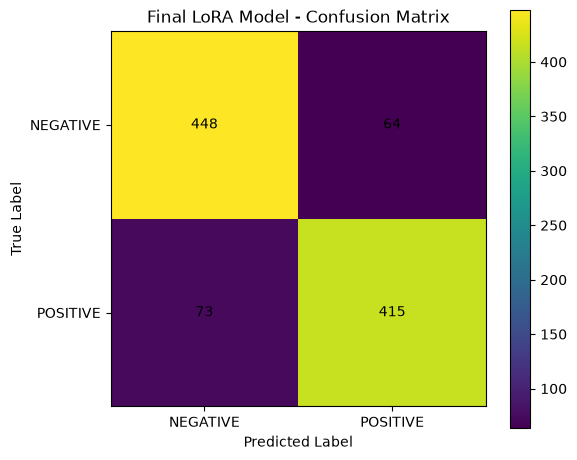

In [197]:
# ===== FINAL MODEL: CONFUSION MATRIX + CLASSIFICATION REPORT =====

import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("===== FINAL MODEL EVALUATION =====")

# Use the already verified final model
final_model.eval()

predictions = []
labels = []

with torch.no_grad():
    for i in range(0, len(test_tokenized), 32):

        batch = test_tokenized[i:i+32]

        input_ids = torch.tensor(
            batch["input_ids"],
            dtype=torch.long
        ).to(device)

        attention_mask = torch.tensor(
            batch["attention_mask"],
            dtype=torch.long
        ).to(device)

        batch_labels = torch.tensor(
            batch["label"],
            dtype=torch.long
        )

        outputs = final_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu().numpy()

        predictions.extend(preds.tolist())
        labels.extend(batch_labels.numpy().tolist())


# ===== METRICS =====

accuracy = accuracy_score(labels, predictions)
precision = precision_score(labels, predictions)
recall = recall_score(labels, predictions)
f1 = f1_score(labels, predictions)

print(f"\nAccuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


# ===== CLASSIFICATION REPORT =====

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        labels,
        predictions,
        target_names=["NEGATIVE", "POSITIVE"]
    )
)


# ===== CONFUSION MATRIX =====

cm = confusion_matrix(labels, predictions)

print("\n===== CONFUSION MATRIX =====")
print(cm)


# ===== PLOT =====

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Final LoRA Model - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["NEGATIVE", "POSITIVE"])
plt.yticks([0, 1], ["NEGATIVE", "POSITIVE"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [198]:
# ===== FINAL MODEL PREDICTION DEMO =====

import torch
import torch.nn.functional as F

def predict_sentiment(text):
    final_model.eval()

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
        if key in ["input_ids", "attention_mask"]
    }

    with torch.no_grad():
        outputs = final_model(**encoded)

        probabilities = F.softmax(
            outputs.logits,
            dim=1
        )

        prediction = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[0][prediction].item()

    label = "POSITIVE" if prediction == 1 else "NEGATIVE"

    return label, confidence


# ===== TEST EXAMPLES =====

test_sentences = [
    "This movie was absolutely fantastic. I loved every minute of it.",
    "The movie was boring, predictable, and disappointing.",
    "I really enjoyed this product and would definitely recommend it.",
    "Terrible experience. I regret buying this.",
    "It was okay, nothing special but not terrible either."
]

print("===== SENTIMENT PREDICTION DEMO =====")

for text in test_sentences:

    label, confidence = predict_sentiment(text)

    print("\nText:", text)
    print("Prediction:", label)
    print(f"Confidence: {confidence:.2%}")

===== SENTIMENT PREDICTION DEMO =====

Text: This movie was absolutely fantastic. I loved every minute of it.
Prediction: POSITIVE
Confidence: 99.62%

Text: The movie was boring, predictable, and disappointing.
Prediction: NEGATIVE
Confidence: 99.38%

Text: I really enjoyed this product and would definitely recommend it.
Prediction: POSITIVE
Confidence: 99.47%

Text: Terrible experience. I regret buying this.
Prediction: NEGATIVE
Confidence: 94.60%

Text: It was okay, nothing special but not terrible either.
Prediction: POSITIVE
Confidence: 81.51%
